# Shapley Methods — Results Analysis

Reusable analysis notebook. Change `DATASET` in the **Configuration** cell and re-run all cells to analyse any experiment run.

Sections:
1. Configuration & Imports
2. Pipeline Timing Summary
3. Load Shapley Values
4. Global Feature Importance Comparison (bar chart)
5. Individual SHAP Scatter Plots — PC Graph
6. Individual SHAP Scatter Plots — LiNGAM Graph

## 1. Configuration & Imports

In [56]:
import sys
from pathlib import Path as _Path
sys.path.insert(0, str(_Path("..").resolve()))

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import json, re
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import importlib
import analysis_utils
importlib.reload(analysis_utils)

from analysis_utils import (
    resolve_features,
    mean_abs_shap, top_k_jaccard,
    compute_sign_agreement, compute_sign_alignment, compute_tga,
    compute_sss, compute_gss,
    edge_recovery, flow_graph_stats, parse_pipeline_timing,
    build_dag_graph, make_dag_pos, draw_dag, draw_dag_highlight, PROX_PALETTE,
    make_shap_scatter_figure, make_instance_shap_figure,
)


In [2]:
# ── Change these two lines to re-run analysis on any dataset ───────────
DATASET        = "linear_conf_f50_s1000_p50"
# DATASET        = "mixed_no_conf_f50_s1000_p50"
MODEL          = "lgbm"

# Number of top features (ranked by ShapleyFromScratch) shown in
# the bar chart (Analysis 4) and scatter grid (Analyses 5 & 6).
N_TOP_FEATURES = 20

# ── Paths (notebook lives in notebooks/, project root is one level up) ──
BASE_DIR           = Path("..").resolve()
EXPLAINABILITY_DIR = BASE_DIR / "data" / "explainability"
CAUSAL_DIR         = BASE_DIR / "data" / "causal"
PROCESSED_DIR      = BASE_DIR / "data" / "processed"
SYNTHETIC_DIR      = BASE_DIR / "data" / "synthetic"
LOGS_DIR           = BASE_DIR / "logs"

# ── Consistent colour scheme across all plots ───────────────────────────
METHOD_COLORS = {
    "Scratch":     "#636363",
    "Asymmetric":  "#2166ac",
    "Causal":      "#4dac26",
    "ShapleyFlow": "#d01c8b",
}

print(f"Dataset : {DATASET}")
print(f"Model   : {MODEL}")
print(f"Top N   : {N_TOP_FEATURES}")
print(f"Synthetic dir exists: {SYNTHETIC_DIR.exists()}")

Dataset : linear_conf_f50_s1000_p50
Model   : lgbm
Top N   : 20
Synthetic dir exists: True


## 2. Pipeline Timing Summary

In [3]:
timing_df, total_time = parse_pipeline_timing(LOGS_DIR, DATASET)

# ── Display as Plotly table ───────────────────────────────────────────────
if timing_df is not None:
    header_vals = list(timing_df.columns)
    cell_vals   = [timing_df[c].tolist() for c in timing_df.columns]

    # Zebra-stripe rows
    n = len(timing_df)
    row_colors = [["#f0f4f8" if i % 2 == 0 else "white" for i in range(n)]] * len(header_vals)

    fig_timing = go.Figure(go.Table(
        header=dict(
            values=[f"<b>{v}</b>" for v in header_vals],
            fill_color="#2c3e50", font=dict(color="white", size=12),
            align="left", height=30,
        ),
        cells=dict(
            values=cell_vals,
            fill_color=row_colors,
            align="left", height=26,
            font=dict(size=11),
        ),
    ))
    fig_timing.update_layout(
        title=dict(
            text=f"Pipeline Timing Summary — {DATASET}<br>"
                 f"<sup>Total execution time: {total_time}</sup>",
            font=dict(size=14),
        ),
        margin=dict(l=10, r=10, t=60, b=10),
        height=90 + 30 + n * 50,
    )
    fig_timing.show()
else:
    print("Could not parse timing log.")

Log file: pipeline_20260511_224553.log


## 3. Load Shapley Values

In [4]:
exp_dir = EXPLAINABILITY_DIR / DATASET / MODEL

# ── Method registry ───────────────────────────────────────────────────────
# key  : display name used across all plots
# value: relative path inside exp_dir
METHOD_PATHS = {
    "Scratch":                exp_dir / "scratch"  / "shapley_values.npy",
    "Asymmetric (PC)":        exp_dir / "pc"       / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":            exp_dir / "pc"       / "causal"     / "shapley_values.npy",
    "Flow (PC)":              exp_dir / "pc"       / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)":   exp_dir / "lingam"   / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":       exp_dir / "lingam"   / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":         exp_dir / "lingam"   / "flow"       / "shapley_values.npy",
}

shap_data = {}
for name, path in METHOD_PATHS.items():
    if path.exists():
        sv = np.load(path)
        shap_data[name] = sv
        nan_pct = 100 * np.isnan(sv).mean()
        zero_pct = 100 * (sv == 0).mean()
        print(f"  {name:28s}  shape={sv.shape}  "
              f"mean|SHAP|={np.abs(sv).mean():.4f}  "
              f"NaN={nan_pct:.1f}%  zeros={zero_pct:.1f}%")
    else:
        print(f"  {name:28s}  NOT FOUND: {path}")

# ── Feature names (X only, no Y) ─────────────────────────────────────────
with open(CAUSAL_DIR / f"{DATASET}_pc_results.json") as f:
    pc_results = json.load(f)
with open(CAUSAL_DIR / f"{DATASET}_lingam_results.json") as f:
    lingam_results = json.load(f)

feature_names = [n for n in pc_results["feature_names"] if n != "Y"]
n_features    = len(feature_names)

# ── Test instances used for SHAP (first n_shap rows of test set) ──────────
n_shap   = shap_data["Scratch"].shape[0]
test_df  = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
x_test   = test_df[feature_names].iloc[:n_shap].values   # shape: (n_shap, n_features)

# ── Graph statistics ──────────────────────────────────────────────────────

pc_edges,     pc_sources     = flow_graph_stats(pc_results["adjacency_matrix"],     n_features)
lingam_edges, lingam_sources = flow_graph_stats(lingam_results["adjacency_matrix"], n_features)

print(f"\nFeatures : {n_features}    SHAP instances : {n_shap}")
print(f"PC graph     : {pc_edges} edges, {pc_sources} sources")
print(f"LiNGAM graph : {lingam_edges} edges, {lingam_sources} sources")

  Scratch                       shape=(100, 50)  mean|SHAP|=0.2906  NaN=0.0%  zeros=0.0%
  Asymmetric (PC)               shape=(100, 50)  mean|SHAP|=0.2975  NaN=0.0%  zeros=0.0%
  Causal (PC)                   shape=(100, 50)  mean|SHAP|=0.3523  NaN=0.0%  zeros=0.0%
  Flow (PC)                     shape=(100, 50)  mean|SHAP|=0.2875  NaN=0.0%  zeros=2.0%
  Asymmetric (LiNGAM)           shape=(100, 50)  mean|SHAP|=0.2949  NaN=0.0%  zeros=0.0%
  Causal (LiNGAM)               shape=(100, 50)  mean|SHAP|=0.3914  NaN=0.0%  zeros=0.0%
  Flow (LiNGAM)                 shape=(100, 50)  mean|SHAP|=0.2022  NaN=0.0%  zeros=0.4%

Features : 50    SHAP instances : 100
PC graph     : 138 edges, 10 sources
LiNGAM graph : 445 edges, 1 sources


## 4. Global Feature Importance Comparison

Mean absolute SHAP value per feature.  
**Left panel** — ShapleyFromScratch + PC-graph methods.  
**Right panel** — ShapleyFromScratch + LiNGAM-graph methods.  
Features are sorted (left → right) by ShapleyFromScratch importance.

In [5]:
# ── Mean absolute SHAP per feature ───────────────────────────────────────
mean_abs = {name: np.abs(sv).mean(axis=0) for name, sv in shap_data.items()}

# Top-N features ranked by Scratch (module-level defaults)
scratch_rank = np.argsort(mean_abs["Scratch"])[::-1][:N_TOP_FEATURES]
top_features = [feature_names[i] for i in scratch_rank]


def _resolve_features(features=None):
    """Thin wrapper — delegates to analysis_utils.resolve_features."""
    return resolve_features(feature_names, scratch_rank, top_features, features)

# ── Method lists (used by scatter / instance cells below) ─────────────────
PC_METHODS     = ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"]
LINGAM_METHODS = ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"]


def plot_feature_importance(features=None):
    """
    Bar chart of mean |SHAP| per feature × method, split by graph type.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display. Defaults to the top-N features ranked
        by Scratch (``N_TOP_FEATURES``).

    Examples
    --------
    >>> plot_feature_importance()                         # default: top-N by Scratch
    >>> plot_feature_importance(['X0', 'X5', 'X12'])      # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"

    rows = []
    for method in PC_METHODS:
        src_key = "Scratch" if method == "Scratch" else method
        if src_key not in mean_abs:
            continue
        label = method.replace(" (PC)", "")
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f"PC  ({pc_edges} edges, {pc_sources} sources)",
                Importance=float(mean_abs[src_key][fi]),
            ))

    for method in LINGAM_METHODS:
        src_key = "Scratch" if method == "Scratch" else method
        if src_key not in mean_abs:
            continue
        label = method.replace(" (LiNGAM)", "")
        for fi in feat_idx:
            rows.append(dict(
                Feature=feature_names[fi],
                Method=label,
                Graph=f"LiNGAM  ({lingam_edges} edges, {lingam_sources} sources)",
                Importance=float(mean_abs[src_key][fi]),
            ))

    df_imp = pd.DataFrame(rows)
    df_imp["Feature"] = pd.Categorical(df_imp["Feature"], categories=feat_labels, ordered=True)

    fig = px.bar(
        df_imp,
        x="Feature", y="Importance", color="Method",
        barmode="group",
        facet_col="Graph",
        facet_col_spacing=0.06,
        category_orders={
            "Feature": feat_labels,
            "Method":  ["Scratch", "Asymmetric", "Causal", "Flow"],
        },
        color_discrete_map={
            "Scratch":     METHOD_COLORS["Scratch"],
            "Asymmetric":  METHOD_COLORS["Asymmetric"],
            "Causal":      METHOD_COLORS["Causal"],
            "Flow":        METHOD_COLORS["ShapleyFlow"],
        },
        labels={"Importance": "Mean |SHAP|", "Feature": ""},
        title=(
            f"Global Feature Importance — {title_tag} Features "
            f"(sorted by Scratch) — {DATASET}"
        ),
        height=480,
        width=1300,
    )
    fig.update_yaxes(matches="y")
    fig.update_layout(legend_title_text="Method", margin=dict(t=80, b=60))
    fig.show()
    return fig


# Default: top-N by Scratch
fig_imp = plot_feature_importance()


## 5. Individual SHAP Scatter Plots — PC Graph

Grid: **rows** = top-N features  ·  **columns** = [Scratch, Asymmetric, Causal, ShapleyFlow]  
Each cell: SHAP value (y) vs. feature value x (x) for all test instances.  
Y-axis scale is **shared within each row** so magnitudes are comparable across methods.

In [6]:
# ── Column metadata ───────────────────────────────────────────────────────
PC_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (PC)",
    "Causal (PC)",
    "Flow (PC)",
]
COL_LABELS = ["ShapleyFromScratch", "AsymmetricShapley", "CausalShapley", "ShapleyFlow"]


def plot_shap_scatter_pc(features=None):
    """
    SHAP value scatter plot (feature value vs SHAP) for PC-graph methods.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display as rows. Defaults to top-N by Scratch.

    Examples
    --------
    >>> plot_shap_scatter_pc()                      # default: top-N by Scratch
    >>> plot_shap_scatter_pc(['X0', 'X5', 'X12'])   # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"
    fig = make_shap_scatter_figure(
        methods        = PC_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        x_test         = x_test,
        shap_data      = shap_data,
        title          = (
            f"SHAP Scatter — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
            f"{title_tag} Features — {DATASET}"
        ),
        colors         = METHOD_COLORS,
    )
    fig.show()
    return fig


# Default: top-N by Scratch
fig_scatter_pc = plot_shap_scatter_pc()


## 6. Individual SHAP Scatter Plots — LiNGAM Graph

Same grid structure as above but using LiNGAM-based causal methods.  
Scratch (no graph) is repeated here as the reference baseline.

In [7]:
LINGAM_SCATTER_METHODS = [
    "Scratch",
    "Asymmetric (LiNGAM)",
    "Causal (LiNGAM)",
    "Flow (LiNGAM)",
]


def plot_shap_scatter_lingam(features=None):
    """
    SHAP value scatter plot (feature value vs SHAP) for LiNGAM-graph methods.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display as rows. Defaults to top-N by Scratch.

    Examples
    --------
    >>> plot_shap_scatter_lingam()                      # default: top-N by Scratch
    >>> plot_shap_scatter_lingam(['X0', 'X5', 'X12'])   # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"
    fig = make_shap_scatter_figure(
        methods        = LINGAM_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        x_test         = x_test,
        shap_data      = shap_data,
        title          = (
            f"SHAP Scatter — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
            f"{title_tag} Features — {DATASET}"
        ),
        colors         = METHOD_COLORS,
    )
    fig.show()
    return fig


# Default: top-N by Scratch
fig_scatter_lingam = plot_shap_scatter_lingam()


## 7. Instance-Level SHAP Values

Select `N_INSTANCES` random test instances and compare the per-feature SHAP values across methods for the **globally-ranked top features**.

| Axis | Meaning |
|------|---------|
| **Rows** | individual test instances |
| **Columns** | Shapley methods |
| **Bars** | SHAP value per feature (🔵 positive contribution, 🔴 negative contribution) |

Feature order is fixed to the global importance ranking (most important at top). This makes it easy to spot how attributions shift across instances and methods.

In [8]:
# ── Instance-Level Config ─────────────────────────────────────────────────
N_INSTANCES = 10
_rng = np.random.default_rng(seed=42)
instance_idx = sorted(_rng.choice(len(x_test), size=N_INSTANCES, replace=False).tolist())
print(f"Selected {N_INSTANCES} instances (seed=42): {instance_idx}")


def plot_instance_shap_pc(features=None):
    """
    Instance-level horizontal bar charts for PC-graph methods.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display per instance. Defaults to top-N by Scratch.

    Examples
    --------
    >>> plot_instance_shap_pc()                      # default: top-N by Scratch
    >>> plot_instance_shap_pc(['X0', 'X5', 'X12'])   # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"
    fig = make_instance_shap_figure(
        methods        = PC_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        instance_idx   = instance_idx,
        shap_data      = shap_data,
        title          = (
            f"Instance-Level SHAP — PC Graph ({pc_edges} edges, {pc_sources} sources) — "
            f"{title_tag} Features — {DATASET}"
        ),
    )
    fig.show()
    return fig


# Default: top-N by Scratch
fig_instance_pc = plot_instance_shap_pc()


Selected 10 instances (seed=42): [8, 9, 19, 41, 60, 68, 71, 82, 94, 96]


In [9]:
def plot_instance_shap_lingam(features=None):
    """
    Instance-level horizontal bar charts for LiNGAM-graph methods.

    Parameters
    ----------
    features : list of str, optional
        Feature names to display per instance. Defaults to top-N by Scratch.

    Examples
    --------
    >>> plot_instance_shap_lingam()                      # default: top-N by Scratch
    >>> plot_instance_shap_lingam(['X0', 'X5', 'X12'])   # specific features
    """
    feat_idx, feat_labels = _resolve_features(features)
    title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"
    fig = make_instance_shap_figure(
        methods        = LINGAM_SCATTER_METHODS,
        col_labels     = COL_LABELS,
        feature_idx    = feat_idx,
        feature_labels = feat_labels,
        instance_idx   = instance_idx,
        shap_data      = shap_data,
        title          = (
            f"Instance-Level SHAP — LiNGAM Graph ({lingam_edges} edges, {lingam_sources} sources) — "
            f"{title_tag} Features — {DATASET}"
        ),
    )
    fig.show()
    return fig


# Default: top-N by Scratch
fig_instance_lingam = plot_instance_shap_lingam()


## 8. Sign Agreement Across Methods

**Metric definition** — for every *(instance i, feature f)* cell we count how many methods assign a positive SHAP value (`n⁺`) and how many assign a negative value (`n⁻`), then define:

$$\text{agreement}(i,f) = \frac{\max(n^+, n^-)}{n_{\text{methods}}} \in [0.5, \; 1.0]$$

| Score | Interpretation |
|-------|---------------|
| **1.0** | All methods agree on the sign (fully consistent) |
| **0.75** | 3 out of 4 methods agree |
| **0.5** | Half say +, half say − (maximally split) |

Three groups are evaluated: **PC Group** (Scratch + 3 PC methods), **LiNGAM Group** (Scratch + 3 LiNGAM methods), **All Methods** (all 7 together).

- **Feature-level bar chart** — mean agreement per feature (averaged over all test instances)
- **Heatmap** — full (feature × instance) agreement matrix, one panel per graph type

In [28]:
# # ── Groups ────────────────────────────────────────────────────────────────
# AGREEMENT_GROUPS = {
#     "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)",     "Flow (PC)"],
#     "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)", "Flow (LiNGAM)"],
#     # "PC Group":     ["Scratch", "Asymmetric (PC)",     "Causal (PC)"],
#     # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Causal (LiNGAM)"],
#     # "PC Group":     ["Scratch", "Asymmetric (PC)",     "Flow (PC)"],
#     # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", "Flow (LiNGAM)"],
#     # "PC Group":     ["Scratch", "Asymmetric (PC)",     ],
#     # "LiNGAM Group": ["Scratch", "Asymmetric (LiNGAM)", ],
#     # "All Methods":  list(shap_data.keys()),
# }
# # AGREEMENT_GROUPS["All Methods"] = AGREEMENT_GROUPS["PC Group"] + AGREEMENT_GROUPS["LiNGAM Group"]
# GROUP_COLORS_AGREE = {
#     "PC Group":     "#1f77b4",
#     "LiNGAM Group": "#e07b39",
#     "All Methods":  "#2ca02c",
# }



# # Module-level state — updated by plot_sign_agreement, consumed by plot_sign_heatmap
# agreement_mats    = {}
# agreement_methods = {}
# _sa_feat_labels   = list(top_features)
# _sa_feat_idx      = scratch_rank.tolist()


# def plot_sign_agreement(features=None):
#     """
#     Compute sign agreement across methods and display the feature-level bar chart.

#     Updates the module-level ``agreement_mats``, ``_sa_feat_labels``, and
#     ``_sa_feat_idx`` so that ``plot_sign_heatmap()`` can be called afterwards
#     without repeating the feature argument.

#     Parameters
#     ----------
#     features : list of str, optional
#         Feature names to analyse. Defaults to top-N by Scratch.

#     Examples
#     --------
#     >>> plot_sign_agreement()                      # default: top-N by Scratch
#     >>> plot_sign_agreement(['X0', 'X5', 'X12'])   # specific features
#     """
#     global agreement_mats, agreement_methods, _sa_feat_labels, _sa_feat_idx

#     feat_idx_list, feat_labels = _resolve_features(features)
#     _sa_feat_idx   = feat_idx_list
#     _sa_feat_labels = feat_labels
#     _feat_idx_arr  = np.array(feat_idx_list)
#     title_tag = f"Top {N_TOP_FEATURES}" if features is None else f"{len(feat_labels)}"

#     # ── Compute ───────────────────────────────────────────────────────────
#     agreement_mats    = {}
#     agreement_methods = {}
#     for grp, methods in AGREEMENT_GROUPS.items():
#         mat, avail             = compute_sign_agreement(methods, shap_data, _feat_idx_arr)
#         agreement_mats[grp]    = mat
#         agreement_methods[grp] = avail

#     # ── Global summary table ──────────────────────────────────────────────
#     print(f"{'Group':<18}  {'Global mean':>11}  {'Feat mean ± std':>18}  {'Inst mean ± std':>18}  # methods")
#     print("─" * 105)
#     for grp, mat in agreement_mats.items():
#         if mat is None:
#             continue
#         feat_means = mat.mean(axis=0)
#         inst_means = mat.mean(axis=1)
#         print(
#             f"{grp:<18}  {mat.mean():>11.3f}  "
#             f"{feat_means.mean():>7.3f} ± {feat_means.std():.3f}    "
#             f"{inst_means.mean():>7.3f} ± {inst_means.std():.3f}  "
#             f"  {len(agreement_methods[grp])}"
#         )

#     # ── Figure A: Feature-level mean sign agreement ───────────────────────
#     rows_agree = []
#     for grp, mat in agreement_mats.items():
#         if mat is None:
#             continue
#         feat_means = mat.mean(axis=0)
#         feat_stds  = mat.std(axis=0)
#         for i, feat in enumerate(feat_labels):
#             rows_agree.append(dict(
#                 Feature=feat,
#                 Group=grp,
#                 Agreement=float(feat_means[i]),
#                 Std=float(feat_stds[i]),
#             ))

#     df_agree_feat = pd.DataFrame(rows_agree)
#     df_agree_feat["Feature"] = pd.Categorical(
#         df_agree_feat["Feature"], categories=feat_labels, ordered=True
#     )

#     fig_agree_feat = px.bar(
#         df_agree_feat,
#         x="Feature", y="Agreement", color="Group",
#         barmode="group",
#         error_y="Std",
#         color_discrete_map=GROUP_COLORS_AGREE,
#         range_y=[0.45, 1.08],
#         title=(
#             f"Feature-Level Sign Agreement — {title_tag} Features — {DATASET}<br>"
#             f"<sup>Mean ± std over all {x_test.shape[0]} test instances.  "
#             f"1.0 = all methods agree on direction, 0.5 = maximally split.</sup>"
#         ),
#         labels={"Agreement": "Mean Sign Agreement", "Feature": ""},
#         height=460, width=1250,
#     )
#     fig_agree_feat.add_hline(
#         y=0.75,
#         line=dict(color="#636363", width=1, dash="dot"),
#         annotation_text="75 % agree",
#         annotation_position="top right",
#         annotation_font_size=10,
#     )
#     fig_agree_feat.add_hline(
#         y=0.5,
#         line=dict(color="#d62728", width=1, dash="dash"),
#         annotation_text="chance (0.5)",
#         annotation_position="bottom right",
#         annotation_font_size=10,
#     )
#     fig_agree_feat.update_layout(
#         legend_title_text="Method Group",
#         margin=dict(t=80, b=80),
#         xaxis_tickangle=-35,
#     )
#     fig_agree_feat.show()
#     return fig_agree_feat


# # Default: top-N by Scratch
# fig_agree_feat = plot_sign_agreement()


In [29]:
# def plot_sign_heatmap(features=None):
#     """
#     Sign agreement heatmap (feature × instance) and instance-level line chart.

#     If ``features`` is provided, re-runs ``plot_sign_agreement(features)`` first
#     to update the shared state. Otherwise uses whatever was last computed by
#     ``plot_sign_agreement()``.

#     Parameters
#     ----------
#     features : list of str, optional
#         Feature names to analyse. Defaults to the features used in the last
#         ``plot_sign_agreement()`` call (top-N by Scratch if never overridden).

#     Examples
#     --------
#     >>> plot_sign_heatmap()                      # uses last plot_sign_agreement() state
#     >>> plot_sign_heatmap(['X0', 'X5', 'X12'])   # re-computes for specific features
#     """
#     if features is not None:
#         plot_sign_agreement(features)   # updates module-level agreement_mats / _sa_feat_labels

#     _mats       = agreement_mats
#     feat_labels = _sa_feat_labels

#     # ── Figure B: Heatmap — feature × all test instances ─────────────────
#     hmap_groups = ["PC Group", "LiNGAM Group"]
#     fig_hmap = make_subplots(
#         rows=1, cols=2,
#         subplot_titles=hmap_groups,
#         horizontal_spacing=0.08,
#     )

#     for ci, grp in enumerate(hmap_groups):
#         mat = _mats[grp]
#         if mat is None:
#             continue

#         z        = mat.T[::-1]
#         y_labels = feat_labels[::-1]

#         fig_hmap.add_trace(
#             go.Heatmap(
#                 z=z,
#                 x=[str(i) for i in range(mat.shape[0])],
#                 y=y_labels,
#                 colorscale="RdYlGn",
#                 zmin=0.5, zmax=1.0,
#                 showscale=(ci == 1),
#                 colorbar=dict(
#                     title=dict(text="Agreement", font=dict(size=11)),
#                     tickvals=[0.50, 0.625, 0.75, 0.875, 1.0],
#                     ticktext=["0.50 (split)", "0.63", "0.75", "0.88", "1.00 (full)"],
#                     x=1.02, len=0.85,
#                 ) if ci == 1 else {},
#                 hovertemplate=(
#                     "<b>%{y}</b><br>"
#                     "Instance %{x}: agreement = %{z:.3f}<extra></extra>"
#                 ),
#             ),
#             row=1, col=ci + 1,
#         )

#         g_mean = mat.mean()
#         fig_hmap.add_annotation(
#             text=f"mean = {g_mean:.3f}",
#             xref=f"x{ci+1 if ci > 0 else ''} domain",
#             yref=f"y{ci+1 if ci > 0 else ''} domain",
#             x=0.98, y=1.04,
#             showarrow=False,
#             font=dict(size=10, color="#2c3e50"),
#             align="right",
#         )

#     fig_hmap.update_layout(
#         title=dict(
#             text=(
#                 f"Sign Agreement Heatmap — Feature × All Test Instances — {DATASET}<br>"
#                 "<sup>Red = split (0.50) · Yellow = partial · Green = full agreement (1.00)</sup>"
#             ),
#             font=dict(size=14),
#         ),
#         height=max(380, 22 * len(feat_labels) + 110),
#         width=1400,
#         margin=dict(l=110, r=100, t=80, b=50),
#     )
#     fig_hmap.update_xaxes(tickfont=dict(size=7), tickangle=-60, title_text="Instance index")
#     fig_hmap.update_yaxes(tickfont=dict(size=9))
#     fig_hmap.show()

#     # ── Figure C: Instance-level mean agreement ───────────────────────────
#     rows_inst = []
#     for grp, mat in _mats.items():
#         if mat is None:
#             continue
#         inst_means = mat.mean(axis=1)
#         for i, v in enumerate(inst_means):
#             rows_inst.append(dict(Instance=i, Group=grp, Agreement=float(v)))

#     df_inst = pd.DataFrame(rows_inst)
#     fig_agree_inst = px.line(
#         df_inst,
#         x="Instance", y="Agreement", color="Group",
#         color_discrete_map=GROUP_COLORS_AGREE,
#         markers=True,
#         range_y=[0.45, 1.05],
#         title=(
#             f"Instance-Level Mean Sign Agreement — {DATASET}<br>"
#             f"<sup>Each point = mean agreement over the {len(feat_labels)} features for that instance.</sup>"
#         ),
#         labels={"Agreement": "Mean Sign Agreement", "Instance": "Test Instance Index"},
#         height=360, width=1100,
#     )
#     fig_agree_inst.add_hline(
#         y=0.75, line=dict(color="#636363", width=1, dash="dot"),
#         annotation_text="75 % agree", annotation_position="top right",
#         annotation_font_size=10,
#     )
#     fig_agree_inst.update_layout(
#         legend_title_text="Method Group",
#         margin=dict(t=80, b=50),
#     )
#     fig_agree_inst.show()
#     return fig_hmap, fig_agree_inst


# # Default: uses state from plot_sign_agreement() above
# fig_hmap, fig_agree_inst = plot_sign_heatmap()


## Section 9 — Causal Graph Structure: PC vs LiNGAM

Visualise the two discovered DAGs side-by-side.
Nodes are coloured by **BFS distance from Y** (sink), making it easy to see:
- how many features directly cause Y (Level 1)
- how deep the causal ancestry goes
- how many source nodes (no parents) each algorithm finds

This also illustrates why ShapleyFlow path-sampling under-weights deep edges:
the backward walk from Y must pass through increasingly rare branch points to reach source-level nodes.


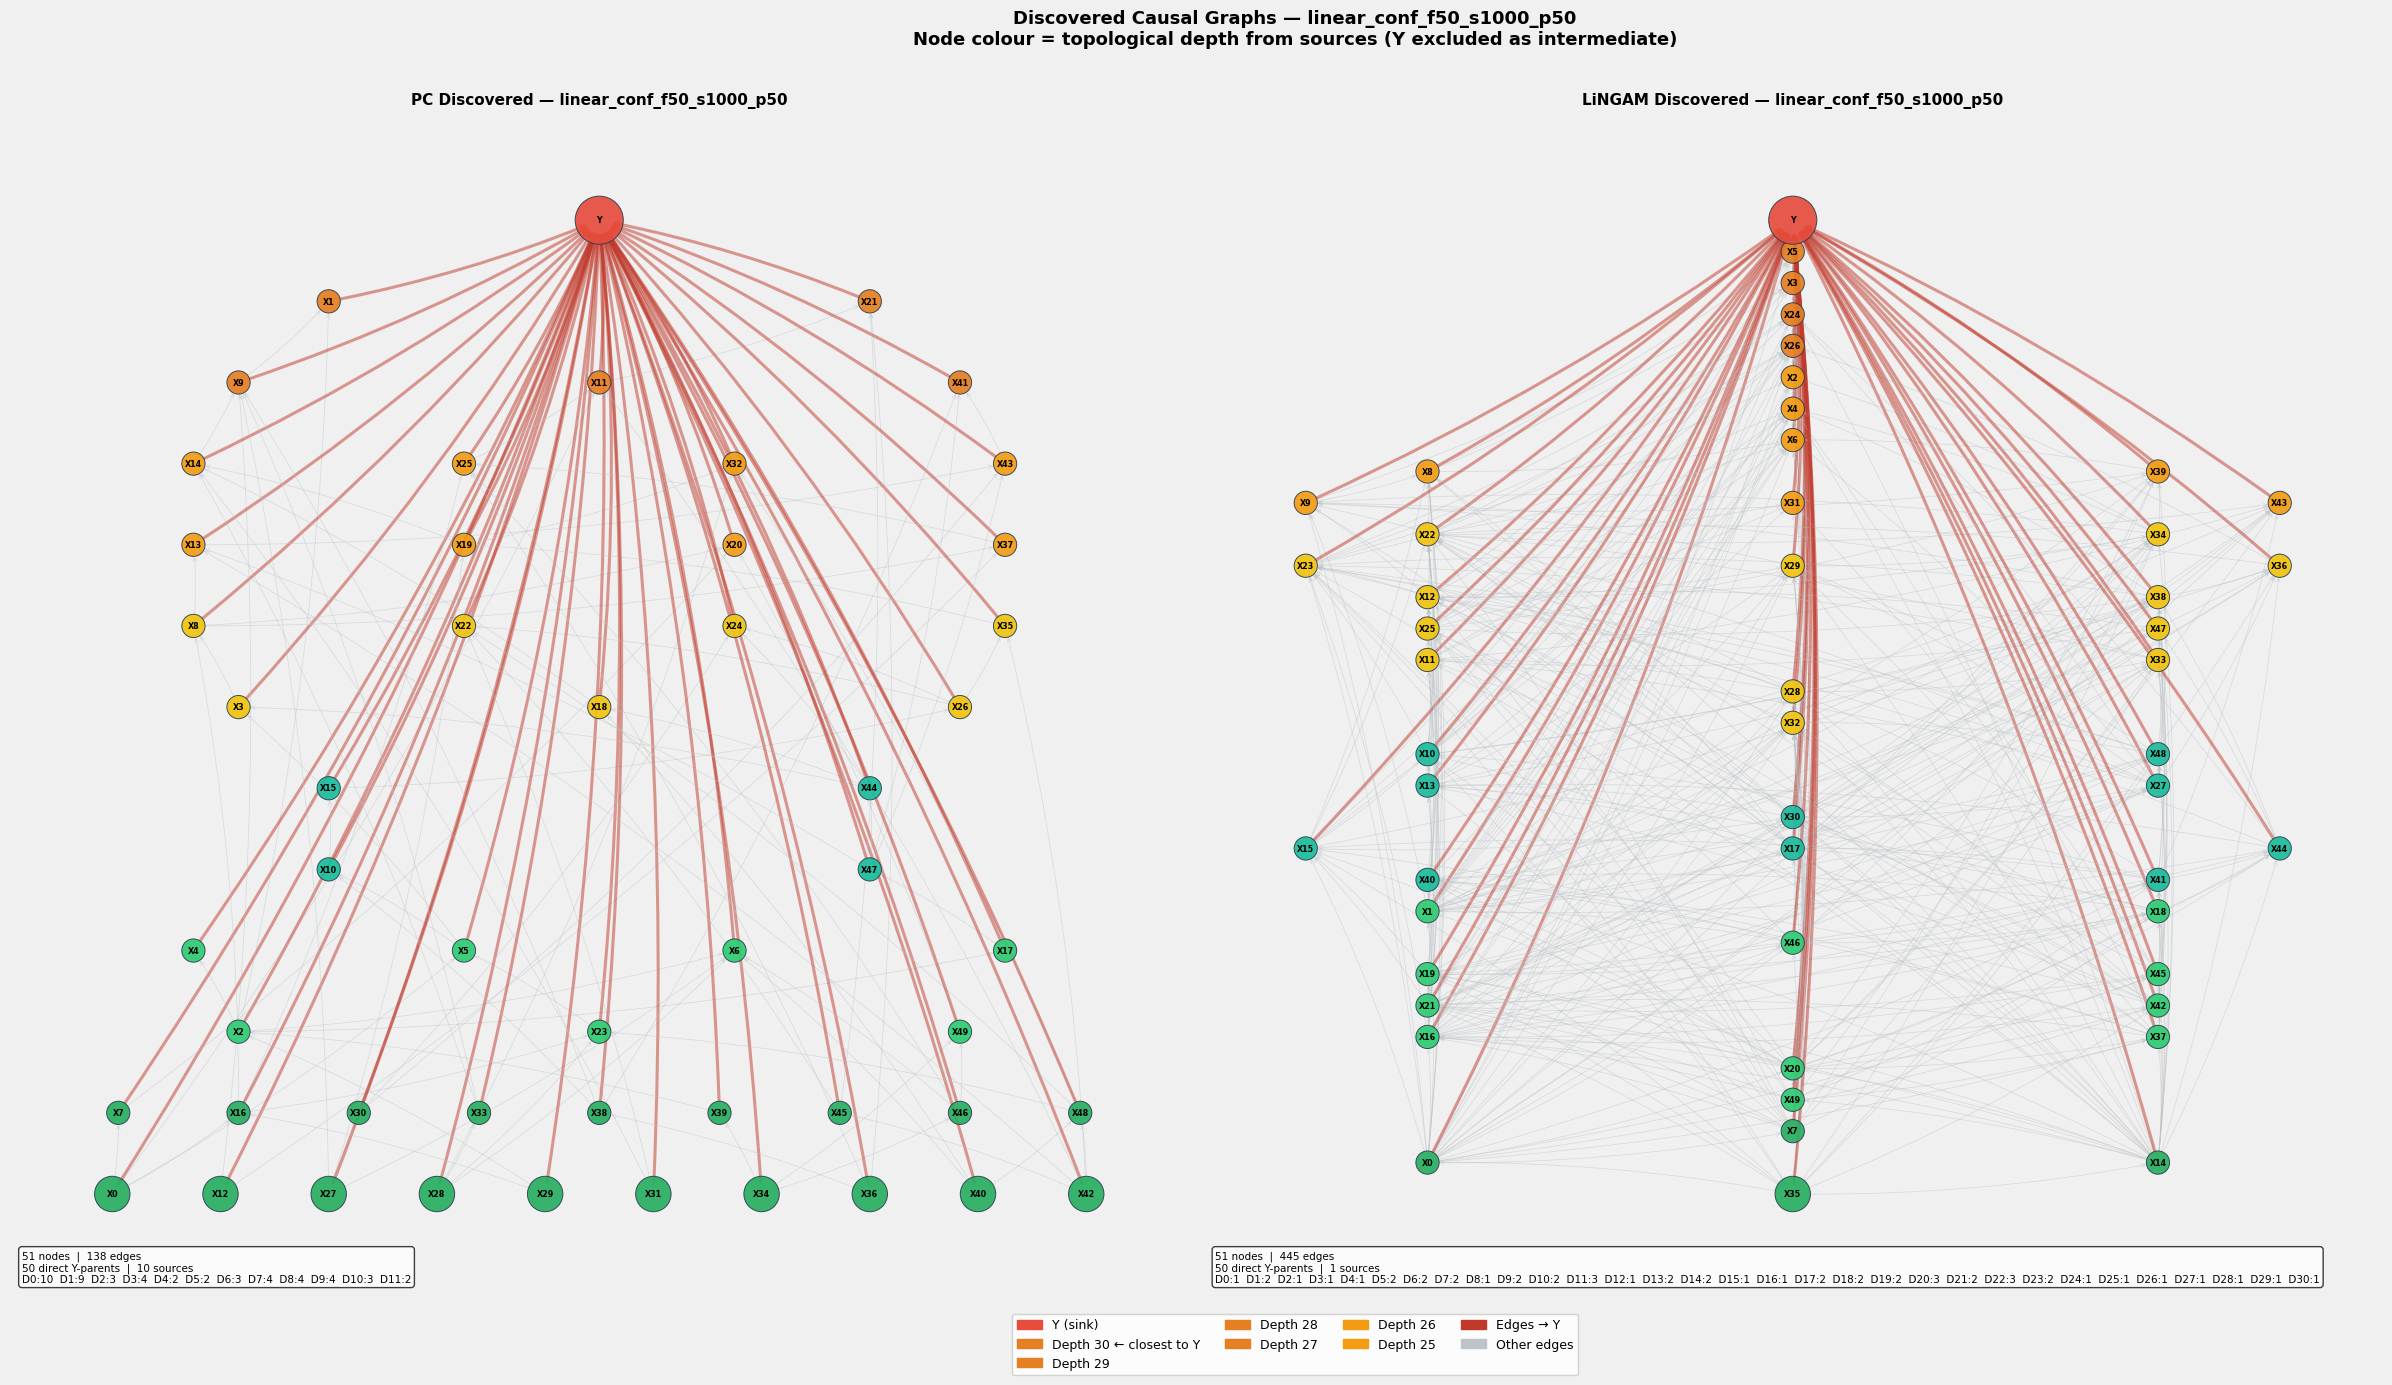

✅  Saved dag_comparison_linear_conf_f50_s1000_p50.png

Metric                                 True         PC     LiNGAM
────────────────────────────────────────────────────────────────
  Total nodes                           51        51        51
  Total edges                          316       138       445
  Direct Y-parents                      50        50        50
  Source nodes (depth 0)                 3        10         1
  Max topo depth                        17        11        30
  Nodes at depth 0                       3        10         1
  Nodes at depth 1                       3         9         2
  Nodes at depth 2                       3         3         1
  Nodes at depth 3                       2         4         1
  Nodes at depth 4                       2         2         1
  Nodes at depth 5                       4         2         2
  Nodes at depth 6                       4         3         2
  Nodes at depth 7                       3         4      

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import collections

# ── Load both discovery results + true adjacency for the current DATASET ─────
def load_dag(causal_dir, dataset, method):
    path = causal_dir / f"{dataset}_{method}_results.json"
    with open(path) as f:
        r = json.load(f)
    return np.array(r["adjacency_matrix"]), r["feature_names"]

pc_adj,     pc_names     = load_dag(CAUSAL_DIR, DATASET, "pc")
lingam_adj, lingam_names = load_dag(CAUSAL_DIR, DATASET, "lingam")

# True adjacency: pipeline-constructed full reference graph (X→X causal structure
# + X→Y for every LGBM selected feature + X→Y for every sink node).
# Same (n+1)×(n+1) shape and feature ordering as the discovered adjacencies.
true_adj   = np.load(CAUSAL_DIR / f"{DATASET}_true_full_adjacency.npy")
true_names = pc_names  # same feature ordering (X0…X{n-1}, Y)

# ── Build all three graphs (also used by the True-graph cell below) ───────────
G_true,   td_true,   lvg_true,   src_true,   y_true,   ml_true   = build_dag_graph(true_adj,   true_names)
G_pc,     td_pc,     lvg_pc,     src_pc,     y_pc,     ml_pc     = build_dag_graph(pc_adj,     pc_names)
G_lingam, td_lingam, lvg_lingam, src_lingam, y_lingam, ml_lingam = build_dag_graph(lingam_adj, lingam_names)

pos_true   = make_dag_pos(lvg_true,   ml_true)
pos_pc     = make_dag_pos(lvg_pc,     ml_pc)
pos_lingam = make_dag_pos(lvg_lingam, ml_lingam)

# ── Draw 2-panel figure: PC | LiNGAM ─────────────────────────────────────────
fig_dags, axes = plt.subplots(1, 2, figsize=(26, 14))
fig_dags.patch.set_facecolor("#f0f0f0")

draw_dag(axes[0], G_pc,     pos_pc,     td_pc,     src_pc,     y_pc,     ml_pc,
         f"PC Discovered — {DATASET}")
draw_dag(axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
         f"LiNGAM Discovered — {DATASET}")

max_lv_disc = max(ml_pc, ml_lingam)
legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), max_lv_disc + 1)):
    idx = int(round(prox / max(max_lv_disc, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = max_lv_disc - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == max_lv_disc
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries.append(mpatches.Patch(color=col, label=lbl))
legend_entries += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                   mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_dags.legend(handles=legend_entries, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_dags.suptitle(
    f"Discovered Causal Graphs — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.savefig(f"dag_comparison_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_comparison_{DATASET}.png")

# ── Comparison table: True | PC | LiNGAM ─────────────────────────────────────
rows = {}
for label, G, td, src, y_i, ml in [
    ("True",   G_true,   td_true,   src_true,   y_true,   ml_true),
    ("PC",     G_pc,     td_pc,     src_pc,     y_pc,     ml_pc),
    ("LiNGAM", G_lingam, td_lingam, src_lingam, y_lingam, ml_lingam),
]:
    rows[label] = {
        "nodes":      G.number_of_nodes(),
        "edges":      G.number_of_edges(),
        "direct_y":   sum(1 for u, v in G.edges() if v == y_i),
        "sources":    len(src),
        "max_depth":  ml,
        "depth_dist": collections.Counter(v for k, v in td.items() if k != y_i),
    }

def _fmt(d, key): return f"{d[key]:>10}"

print(f"\n{'Metric':<32} {'True':>10} {'PC':>10} {'LiNGAM':>10}")
print("─" * 64)
print(f"  {'Total nodes':<30}"            + "".join(_fmt(rows[m], "nodes")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Total edges':<30}"            + "".join(_fmt(rows[m], "edges")    for m in ["True","PC","LiNGAM"]))
print(f"  {'Direct Y-parents':<30}"       + "".join(_fmt(rows[m], "direct_y") for m in ["True","PC","LiNGAM"]))
print(f"  {'Source nodes (depth 0)':<30}" + "".join(_fmt(rows[m], "sources")  for m in ["True","PC","LiNGAM"]))
print(f"  {'Max topo depth':<30}"         + "".join(_fmt(rows[m], "max_depth") for m in ["True","PC","LiNGAM"]))
max_d_all = max(rows[m]["max_depth"] for m in rows)
for d in range(max_d_all + 1):
    note = " (closest to Y)" if d == max_d_all else ""
    vals = "".join(f"{rows[m]['depth_dist'].get(d, 0):>10}" for m in ["True","PC","LiNGAM"])
    print(f"  {'Nodes at depth ' + str(d) + note:<30}" + vals)

# ── Edge recovery metrics (vs true_full_adjacency) ────────────────────────────

pc_prec,     pc_rec,     pc_f1     = edge_recovery(true_adj, pc_adj)
lingam_prec, lingam_rec, lingam_f1 = edge_recovery(true_adj, lingam_adj)

print(f"\n{'Edge Recovery vs true_full_adj':<32} {'PC':>10} {'LiNGAM':>10}")
print("─" * 54)
print(f"  {'Precision':<30} {pc_prec:>10.3f} {lingam_prec:>10.3f}")
print(f"  {'Recall':<30} {pc_rec:>10.3f} {lingam_rec:>10.3f}")
print(f"  {'F1':<30} {pc_f1:>10.3f} {lingam_f1:>10.3f}")


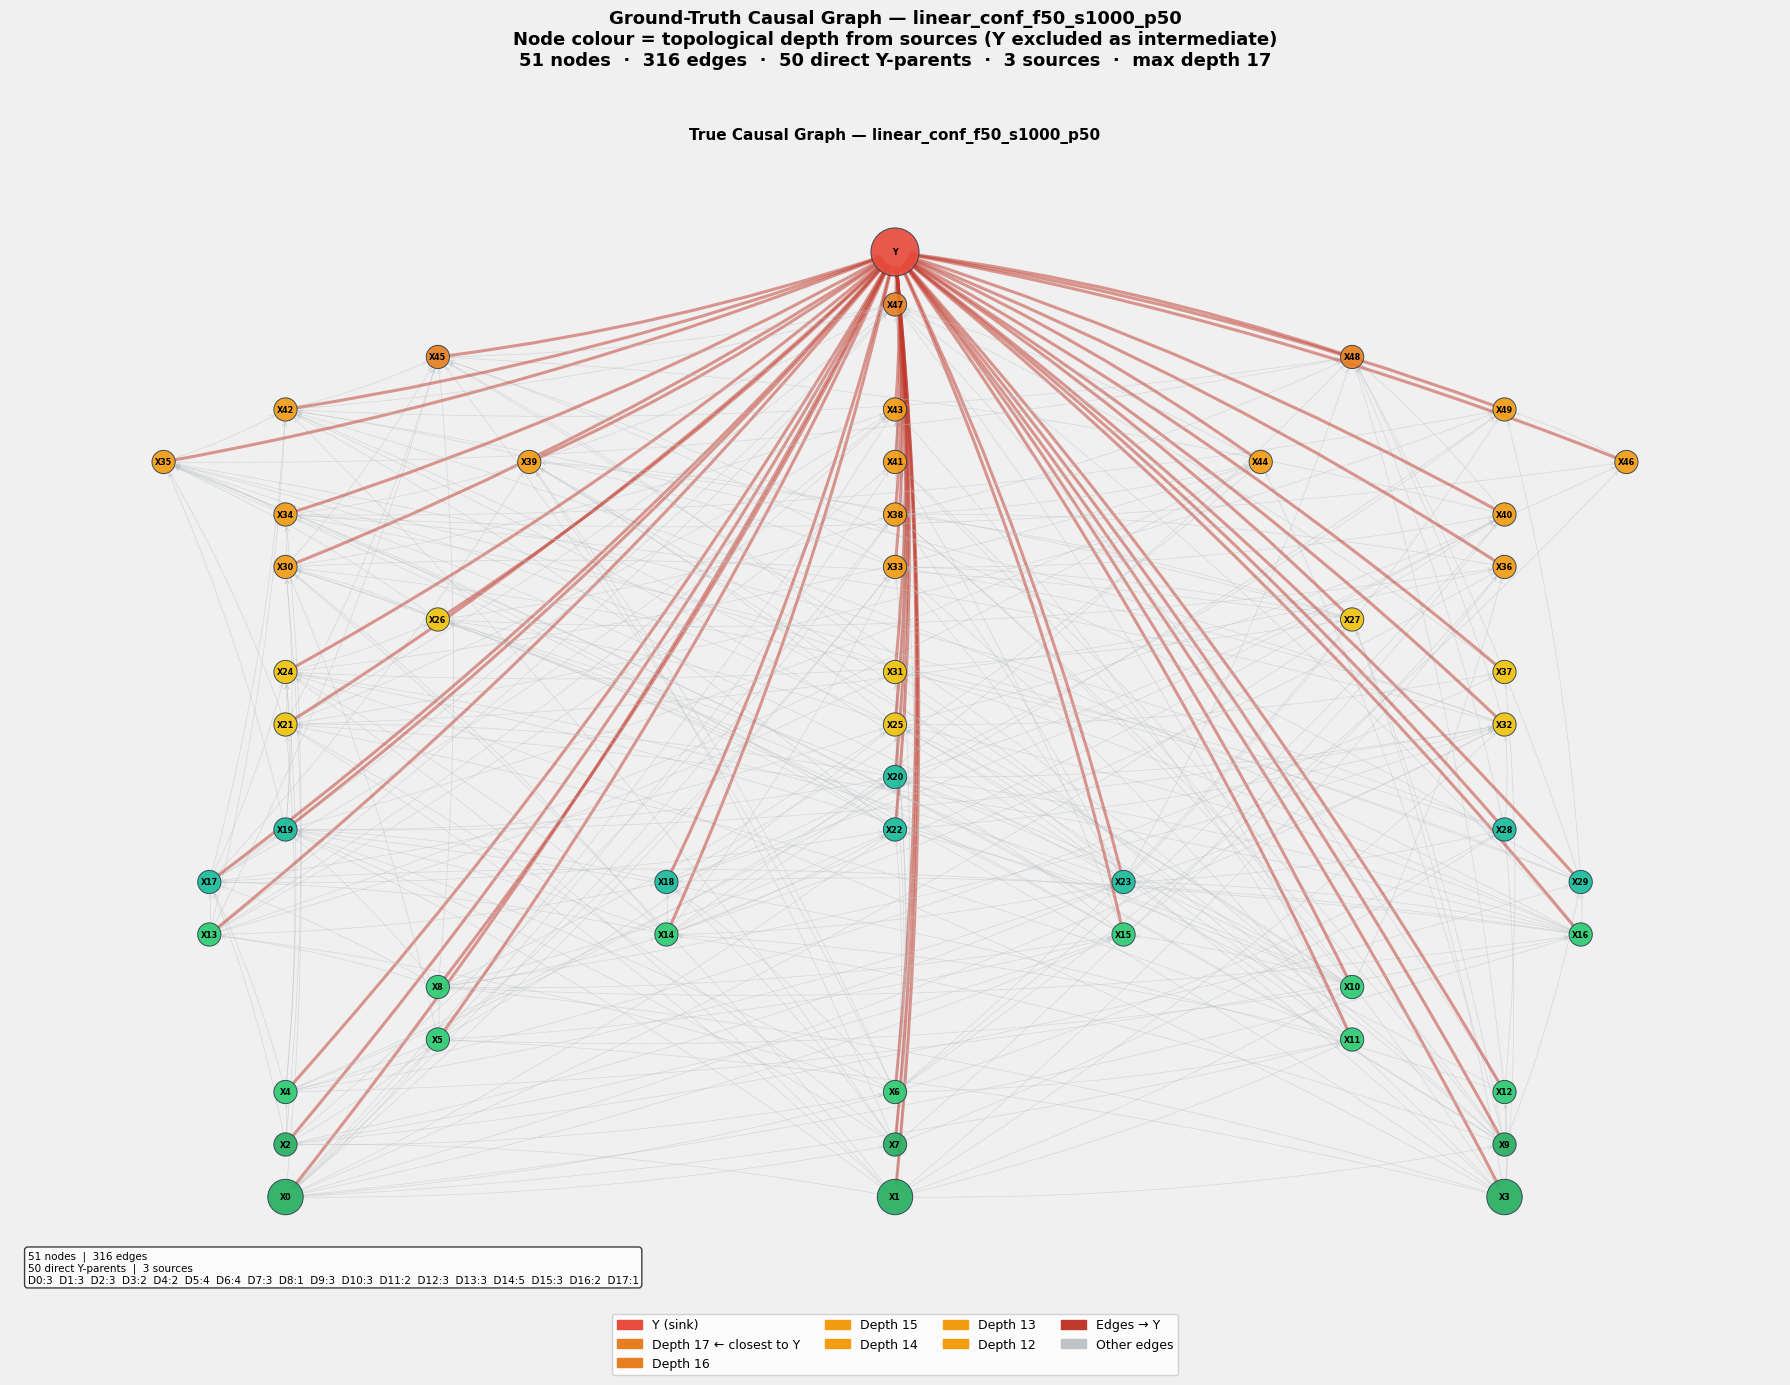

✅  Saved dag_true_linear_conf_f50_s1000_p50.png


In [13]:
# ── True (ground-truth) causal graph — standalone panel ──────────────────────
fig_true, ax_true = plt.subplots(1, 1, figsize=(18, 14))
fig_true.patch.set_facecolor("#f0f0f0")

draw_dag(ax_true, G_true, pos_true, td_true, src_true, y_true, ml_true,
         f"True Causal Graph — {DATASET}")

# Legend
legend_entries_true = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), ml_true + 1)):
    idx = int(round(prox / max(ml_true, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    d   = ml_true - prox
    lbl = (f"Depth {d} — sources (no parents)" if prox == ml_true
           else f"Depth {d}" + (" ← closest to Y" if prox == 0 else ""))
    legend_entries_true.append(mpatches.Patch(color=col, label=lbl))
legend_entries_true += [mpatches.Patch(color="#c0392b", label="Edges → Y"),
                        mpatches.Patch(color="#bdc3c7", label="Other edges")]
fig_true.legend(handles=legend_entries_true, loc="lower center", ncol=4, fontsize=9,
                framealpha=0.85, bbox_to_anchor=(0.5, 0.01))

fig_true.suptitle(
    f"Ground-Truth Causal Graph — {DATASET}\n"
    f"Node colour = topological depth from sources (Y excluded as intermediate)\n"
    f"{G_true.number_of_nodes()} nodes  ·  {G_true.number_of_edges()} edges  ·  "
    f"{sum(1 for u,v in G_true.edges() if v==y_true)} direct Y-parents  ·  "
    f"{len(src_true)} sources  ·  max depth {ml_true}",
    fontsize=13, fontweight="bold", y=0.99,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.savefig(f"dag_true_{DATASET}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅  Saved dag_true_{DATASET}.png")

## Section 9b — DAG Node Highlight

Highlight a specific feature node in both PC and LiNGAM graphs to understand its causal role.  
**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted so the focal node stands out clearly.

In/out degree and topological depth are annotated at the bottom-left of each panel.  
Use this after Section 8 diagnostics to inspect features with high GSS, low SSS, or large rank shifts.

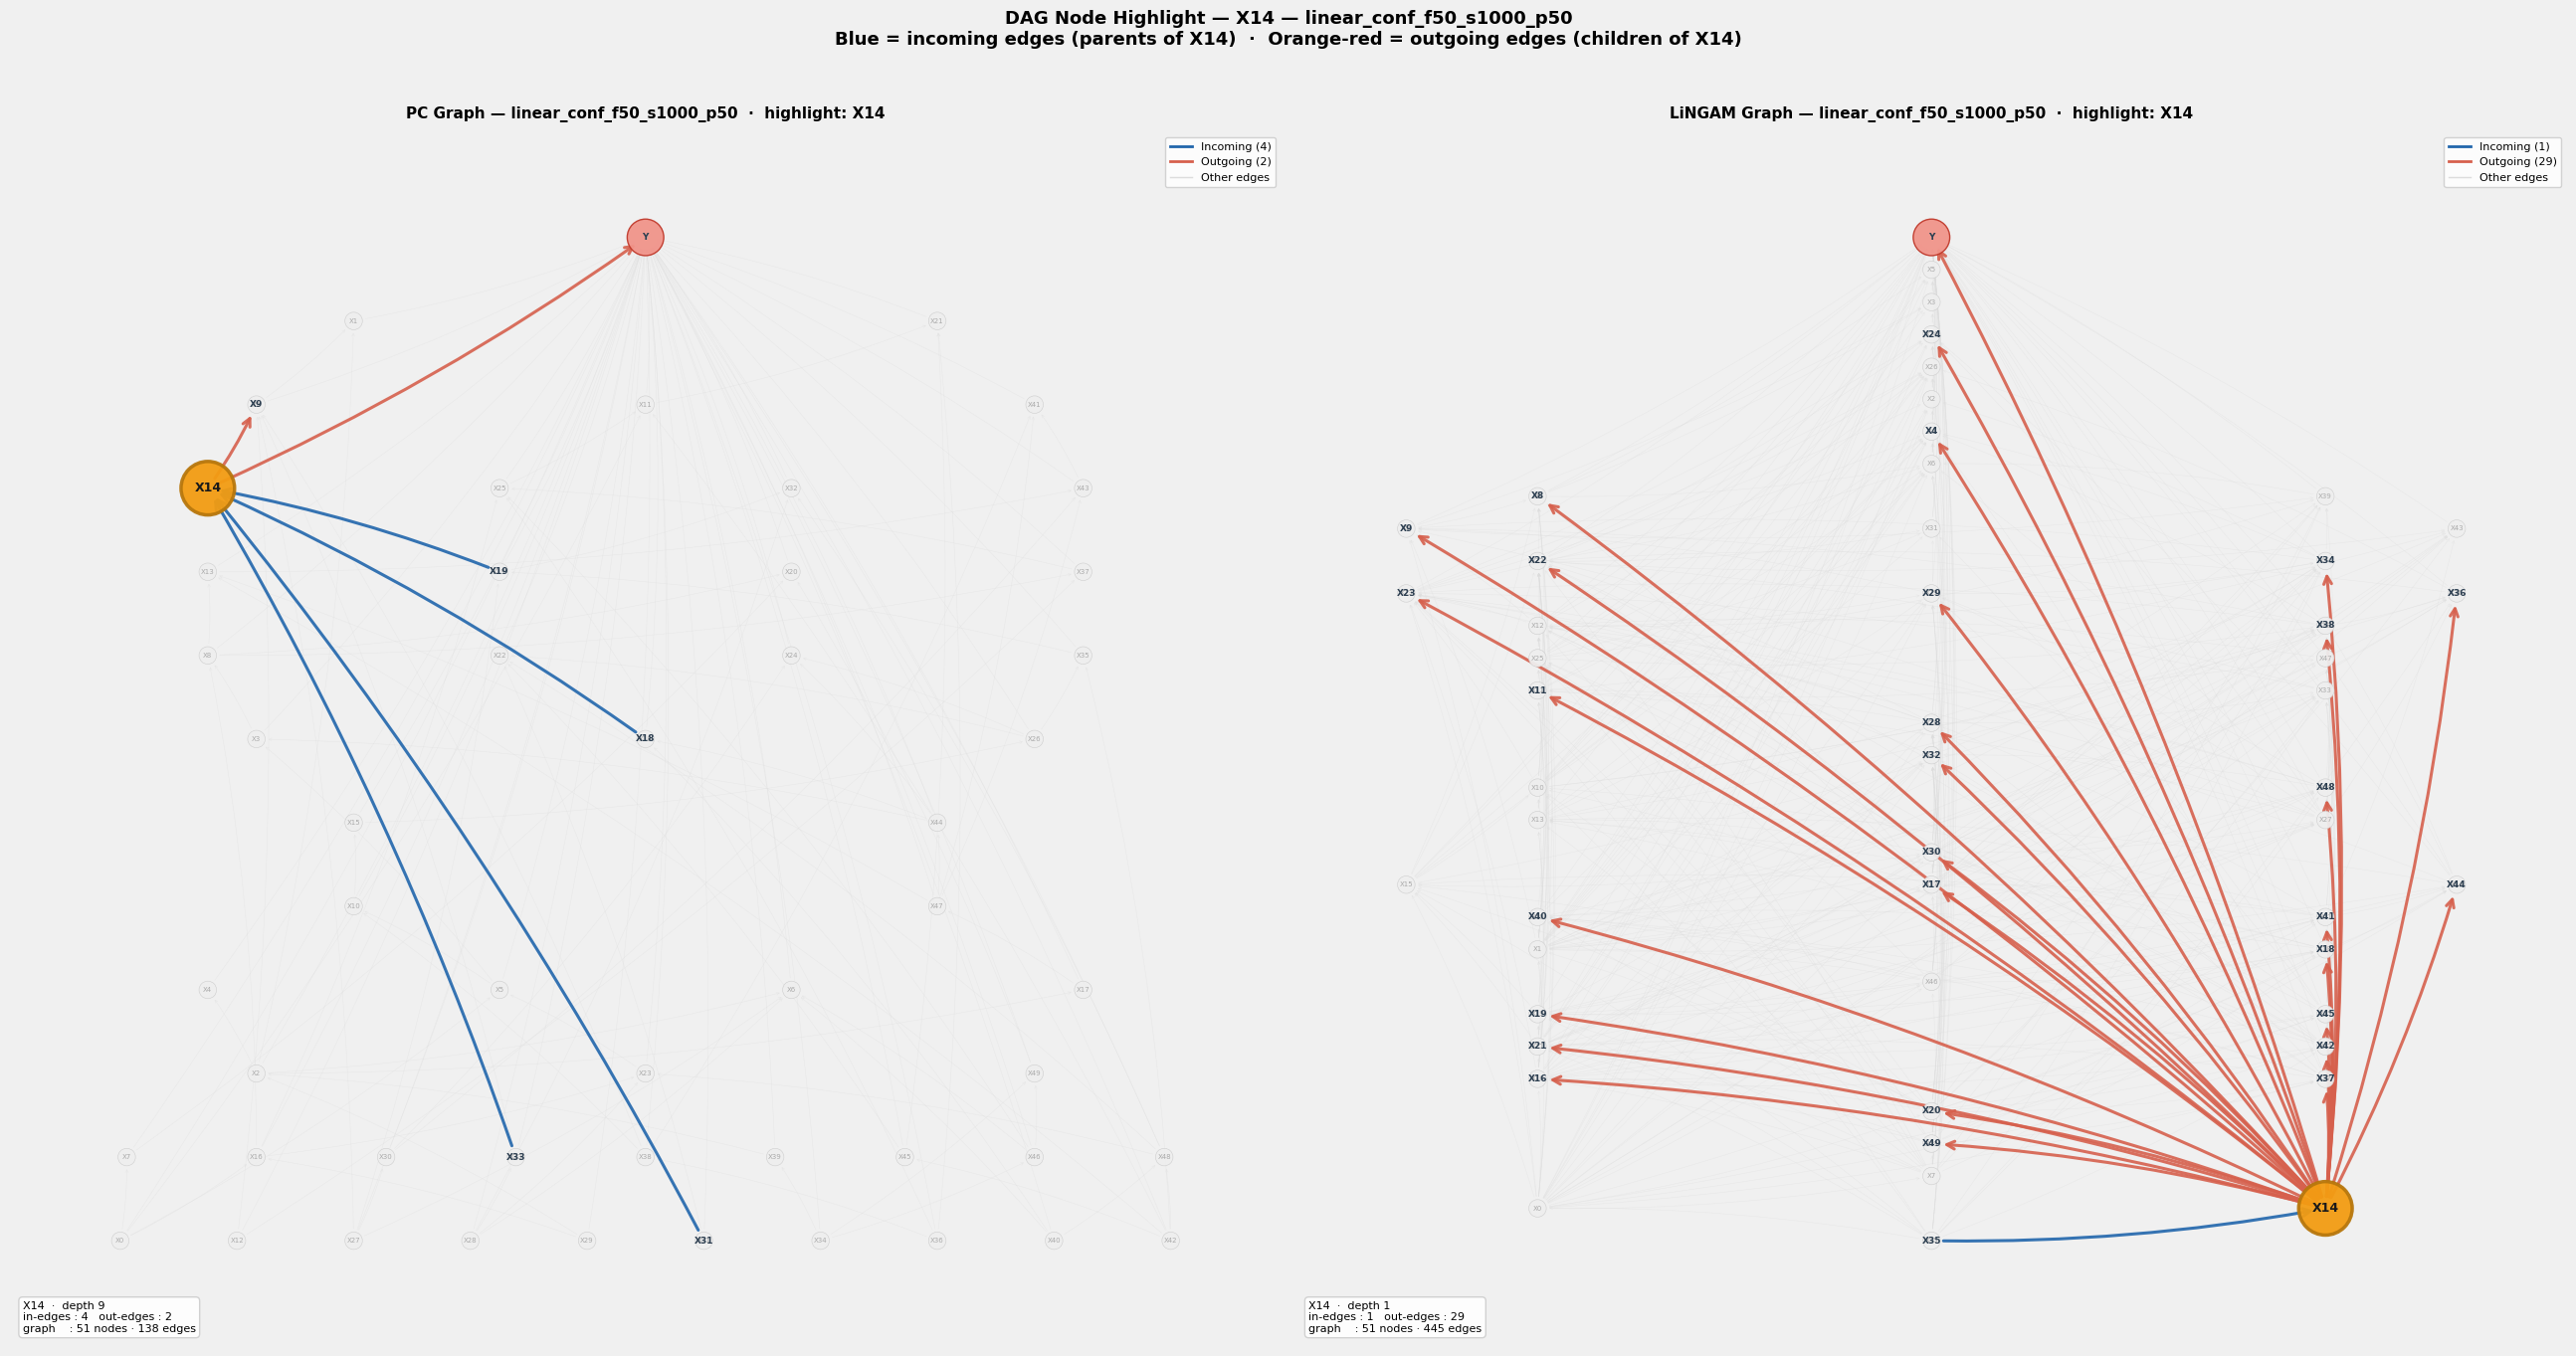

In [82]:
import matplotlib.pyplot as plt


def plot_dag_highlight(feature_name: str, figsize=(26, 14)):
    """
    Draw PC and LiNGAM DAGs side by side with one feature node highlighted.

    Parameters
    ----------
    feature_name : str
        Name of the feature to highlight, e.g. "X5" or "X21".
    figsize : tuple
        Figure size (width, height).
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.patch.set_facecolor("#f0f0f0")

    draw_dag_highlight(
        axes[0], G_pc, pos_pc, td_pc, src_pc, y_pc, ml_pc,
        title=f"PC Graph — {DATASET}  ·  highlight: {feature_name}",
        highlight_name=feature_name,
        names=pc_names,
    )
    draw_dag_highlight(
        axes[1], G_lingam, pos_lingam, td_lingam, src_lingam, y_lingam, ml_lingam,
        title=f"LiNGAM Graph — {DATASET}  ·  highlight: {feature_name}",
        highlight_name=feature_name,
        names=pc_names,   # same feature ordering
    )

    fig.suptitle(
        f"DAG Node Highlight — {feature_name} — {DATASET}\n"
        f"Blue = incoming edges (parents of {feature_name})  ·  "
        f"Orange-red = outgoing edges (children of {feature_name})",
        fontsize=13, fontweight="bold", y=0.99,
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


# ── Example usage ─────────────────────────────────────────────────────────────
# Change the feature name to any node visible in Section 9 graphs,
# e.g. features identified as most unstable/stable from Section 8 diagnostics.
plot_dag_highlight("X14")

## Section 9c — True DAG Node Highlight

Same highlight visualisation as Section 9b but drawn on the **ground-truth causal graph**.  
Use this alongside the PC / LiNGAM highlights to compare the node's true causal neighbourhood
against what each discovery algorithm found.

**Blue** arrows = incoming edges (parents of the node).  
**Orange-red** arrows = outgoing edges (children of the node).  
All other nodes and edges are muted.


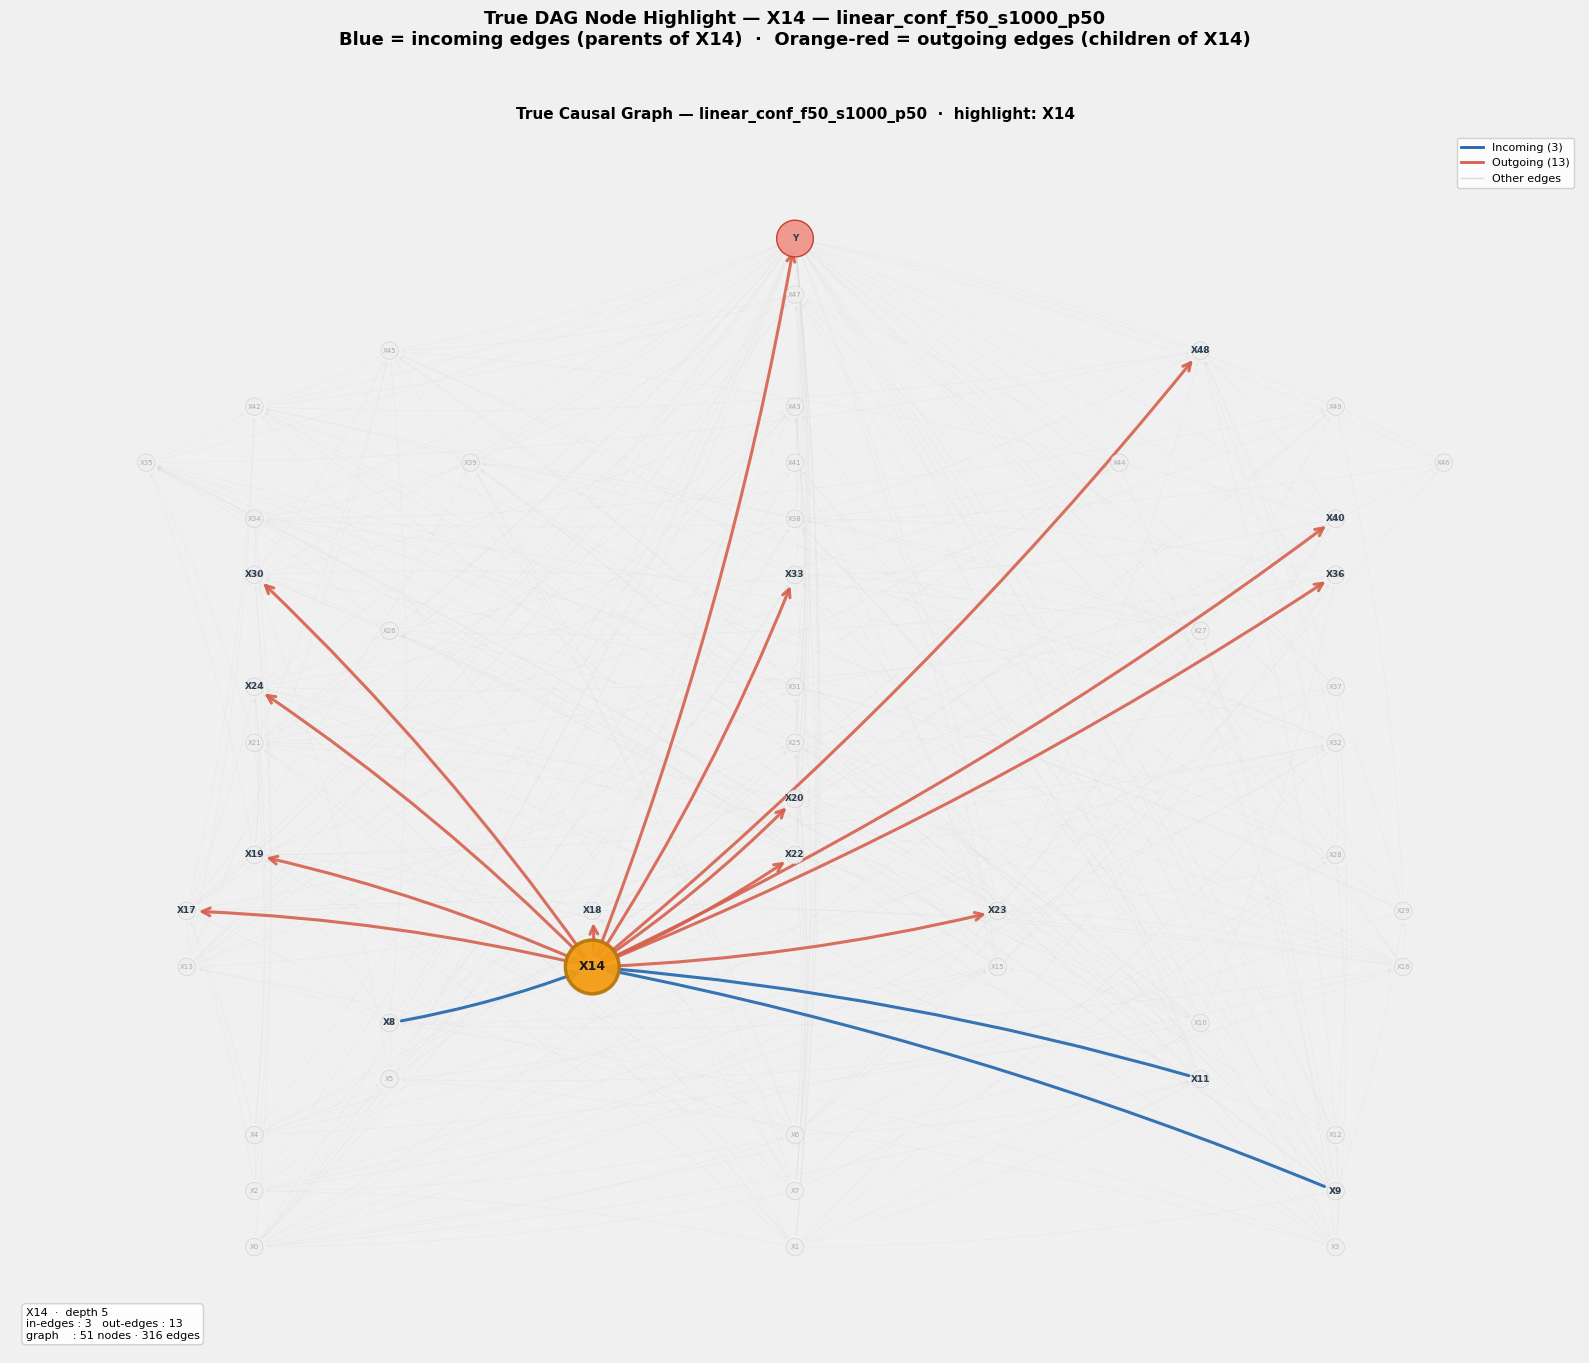

In [83]:
import matplotlib.pyplot as plt


def plot_dag_highlight_true(feature_name: str, figsize=(16, 14)):
    """
    Draw the True (ground-truth) causal DAG with one feature node highlighted.

    The layout is the same topological layout used by draw_dag / plot_dag_highlight,
    so the node positions are consistent across Section 9b and 9c.

    Parameters
    ----------
    feature_name : str
        Name of the feature to highlight, e.g. "X5" or "X21".
    figsize : tuple
        Figure size (width, height).
    """
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.patch.set_facecolor("#f0f0f0")

    draw_dag_highlight(
        ax, G_true, pos_true, td_true, src_true, y_true, ml_true,
        title=f"True Causal Graph — {DATASET}  ·  highlight: {feature_name}",
        highlight_name=feature_name,
        names=true_names,
    )

    fig.suptitle(
        f"True DAG Node Highlight — {feature_name} — {DATASET}\n"
        f"Blue = incoming edges (parents of {feature_name})  ·  "
        f"Orange-red = outgoing edges (children of {feature_name})",
        fontsize=13, fontweight="bold", y=0.99,
    )
    plt.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


# ── Example usage ─────────────────────────────────────────────────────────────
# Use the same feature name as in plot_dag_highlight() to compare the true
# causal neighbourhood against the PC and LiNGAM discovered neighbourhoods.
plot_dag_highlight_true("X14")


## Section 10 — Graph Sensitivity Analysis

**Goal**: quantify how much the choice of discovered graph (PC vs LiNGAM vs ground truth) changes the attributions produced by each causal Shapley method. This lets us answer the key thesis question:

> *Which method is causally aware but robust to graph quality?*

### Strategy

| Step | Metric | Graph variants | Instances used |
|------|--------|----------------|----------------|
| 10.1 | Load pre-computed Shapley values from pipeline output | All (PC / LiNGAM / True) | All pipeline test instances (~100) |
| 10.2 | **Graph Sensitivity Score (GSS)** — normalized MAD between PC and LiNGAM attributions per feature | PC vs LiNGAM | All pre-computed instances |
| 10.3 | **Spearman ρ / Top-K Jaccard** — ranking robustness across graph variants | PC vs LiNGAM vs True | All pre-computed instances |
| 10.4 | **True-graph alignment** — distance from gold-standard attributions | PC→True, LiNGAM→True | All pre-computed instances |
| 10.5 | **Recommendation summary** — one score per method | All variants | — |

> **Run Section 3 first** (cells through "Load Shapley Values") to populate `shap_data`, `feature_names`, `x_test`, etc.


In [15]:
"""
10.1 — Load pre-computed Shapley values (all 3 methods × 3 graphs) from pipeline output.

The pipeline (calculate_all_shapley_values) already computed and saved every combination
to data/explainability/{DATASET}/lgbm/{graph}/{method}/shapley_values.npy.
No re-computation or caching is needed here.
"""
_exp_base = EXPLAINABILITY_DIR / DATASET / "lgbm"

PIPELINE_KEYS = {
    "Asymmetric (PC)":     _exp_base / "pc"     / "asymmetric" / "shapley_values.npy",
    "Causal (PC)":         _exp_base / "pc"     / "causal"     / "shapley_values.npy",
    "Flow (PC)":           _exp_base / "pc"     / "flow"       / "shapley_values.npy",
    "Asymmetric (LiNGAM)": _exp_base / "lingam" / "asymmetric" / "shapley_values.npy",
    "Causal (LiNGAM)":     _exp_base / "lingam" / "causal"     / "shapley_values.npy",
    "Flow (LiNGAM)":       _exp_base / "lingam" / "flow"       / "shapley_values.npy",
    "Asymmetric (True)":   _exp_base / "true"   / "asymmetric" / "shapley_values.npy",
    "Causal (True)":       _exp_base / "true"   / "causal"     / "shapley_values.npy",
    "Flow (True)":         _exp_base / "true"   / "flow"       / "shapley_values.npy",
}

subset_shap_data = {}
for key, path in PIPELINE_KEYS.items():
    if path.exists():
        subset_shap_data[key] = np.load(path)
    else:
        print(f"⚠️  Missing: {path}")

# ── Auxiliary variables expected by downstream cells ─────────────────────────
_train_tmp    = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_train.parquet")
_test_tmp     = pd.read_parquet(PROCESSED_DIR / f"{DATASET}_test.parquet")
feat_names_10 = [c for c in _train_tmp.drop(columns=["Y"]).columns]

X_train_10 = _train_tmp.drop(columns=["Y"]); y_train_10 = _train_tmp["Y"]
X_test_10  = _test_tmp.drop(columns=["Y"]);  y_test_10  = _test_tmp["Y"]

RANDOM_STATE_10 = 42
N_TRUE_INSTANCES = list(subset_shap_data.values())[0].shape[0]

true_adj_xx         = true_adj[:len(feat_names_10), :len(feat_names_10)]
pc_train_adj_xx     = np.load(CAUSAL_DIR / f"{DATASET}_pc_train_adjacency.npy")
lingam_train_adj_xx = np.load(CAUSAL_DIR / f"{DATASET}_lingam_train_adjacency.npy")

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"✅  Loaded {len(subset_shap_data)} arrays from pipeline output.")
print(f"    Instances per array: {N_TRUE_INSTANCES}  |  Features: {list(subset_shap_data.values())[0].shape[1]}\n")
print(f"{'Key':<28}  {'Shape':>14}  {'mean|φ|':>9}  {'zeros%':>7}")
print("─" * 65)
for k, v in subset_shap_data.items():
    print(f"  {k:<26}  {str(v.shape):>14}  {np.abs(v).mean():>9.4f}  {100*(v==0).mean():>6.1f}%")


✅  Loaded 9 arrays from pipeline output.
    Instances per array: 100  |  Features: 50

Key                                    Shape    mean|φ|   zeros%
─────────────────────────────────────────────────────────────────
  Asymmetric (PC)                  (100, 50)     0.2975     0.0%
  Causal (PC)                      (100, 50)     0.3523     0.0%
  Flow (PC)                        (100, 50)     0.2875     2.0%
  Asymmetric (LiNGAM)              (100, 50)     0.2949     0.0%
  Causal (LiNGAM)                  (100, 50)     0.3914     0.0%
  Flow (LiNGAM)                    (100, 50)     0.2022     0.4%
  Asymmetric (True)                (100, 50)     0.2967     0.0%
  Causal (True)                    (100, 50)     0.3772     0.0%
  Flow (True)                      (100, 50)     0.2334     0.6%


## 10.2 — Graph Sensitivity Score (GSS)

The **Graph Sensitivity Score** measures how much the choice of causal discovery algorithm (PC vs LiNGAM) changes the **importance magnitude** assigned to each feature. It operates on absolute Shapley values so that sign flips that preserve magnitude do not inflate the score:

$$
\text{GSS}(m, f) = \frac{\displaystyle\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m,\,\text{PC})}_{i,f}| - |\varphi^{(m,\,\text{LiNGAM})}_{i,f}|\,\Bigr|}{\displaystyle\max_{m'}\;\frac{1}{n}\sum_{i=1}^{n}\Bigl|\,|\varphi^{(m',\,\text{PC})}_{i,f}| - |\varphi^{(m',\,\text{LiNGAM})}_{i,f}|\,\Bigr|}
$$

where $m$ is the causal Shapley method (Asymmetric, Causal, Flow), $f$ is a feature, $n$ is the number of instances, and $\varphi^{(m,\,g)}_{i,f}$ is the Shapley value of feature $f$ for instance $i$ under method $m$ with graph $g$.

The denominator is the **per-feature maximum** of this magnitude difference across methods, bounding **GSS $\in [0,\,1]$** for every feature:

- **GSS = 0** — both graphs assign the same importance magnitude (the feature matters equally under PC and LiNGAM).
- **GSS = 1** — this method shows the largest importance-magnitude shift for this feature across all methods.

This normalisation answers: *"relative to the most sensitive method, how much does graph choice change the importance of feature $f$ for method $m$?"* A method with low mean GSS is **robust** to which causal discovery algorithm was used.

In [24]:
"""
10.2 — Graph Sensitivity Score (GSS): PC vs LiNGAM

Uses the full pre-computed shap_data (all n_shap instances).
Shows:
  A) Feature-level GSS heatmap  — which features are most sensitive to graph choice?
  B) Per-instance magnitude delta box plots — top features by Scratch importance
  C) Method-level GSS summary table

GSS(method, feature) = mean_i ( |φ(PC,i,f)| - |φ(LiNGAM,i,f)| )

No outer absolute, no normalisation — the sign encodes direction:
→ GSS > 0 : PC assigns higher mean absolute importance for this feature.
→ GSS < 0 : LiNGAM assigns higher mean absolute importance for this feature.
→ GSS ≈ 0 : both graphs agree on magnitude for this feature.
Averaging over features gives the overall directional bias of a method.
"""

CAUSAL_METHOD_PAIRS = [
    ("Asymmetric", "Asymmetric (PC)",  "Asymmetric (LiNGAM)"),
    ("Causal",     "Causal (PC)",      "Causal (LiNGAM)"),
    ("Flow",       "Flow (PC)",        "Flow (LiNGAM)"),
]

# ── Compute signed magnitude delta ──────────────────────────────────────────
# |φ(PC)| - |φ(LiNGAM)| per instance, then averaged over instances
feat_delta = {}
gss_feat   = {}
for label, pc_key, lingam_key in CAUSAL_METHOD_PAIRS:
    if pc_key not in shap_data or lingam_key not in shap_data:
        continue
    abs_pc     = np.abs(shap_data[pc_key])               # (n_inst, n_feat)
    abs_lingam = np.abs(shap_data[lingam_key])           # (n_inst, n_feat)
    feat_delta[label] = abs_pc - abs_lingam              # signed per-instance delta
    gss_feat[label]   = feat_delta[label].mean(axis=0)   # signed mean per feature

for label in ["Asymmetric", "Causal", "Flow"]:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f"{label}: mean GSS = {np.mean(g):.4f}  "
          f"min GSS = {np.min(g):.4f}  max GSS = {np.max(g):.4f}")

# ── A: Feature-level GSS heatmap (methods = rows, features = cols) ─────────────
gss_matrix = np.stack([gss_feat[m] for m in ["Asymmetric","Causal","Flow"]], axis=1)
# sort features by mean |GSS| descending → highest-magnitude disagreement on the left
feat_order     = np.argsort(np.abs(gss_matrix).mean(axis=1))[::-1]
top_feats_gss  = min(40, len(feature_names))
feat_order_top = feat_order[:top_feats_gss]

METHOD_LABELS = ["Asymmetric", "Causal", "Flow"]
# Transpose so z shape is (n_methods, n_feats) → methods on y, features on x
gss_z_T   = gss_matrix[feat_order_top].T   # (3, top_feats_gss)
abs_max   = float(np.nanmax(np.abs(gss_matrix)))

fig_gss_hmap = go.Figure(go.Heatmap(
    z          = gss_z_T,
    y          = METHOD_LABELS,
    x          = [feature_names[i] for i in feat_order_top],
    colorscale = "RdBu",
    zmid=0,
    zmin=-abs_max, zmax=abs_max,
    colorbar=dict(
        title=dict(text="GSS", font=dict(size=11)),
    ),
    hovertemplate="<b>%{y}</b> — %{x}<br>GSS = %{z:.4f}<extra></extra>",
))
fig_gss_hmap.update_layout(
    title=dict(
        text=(
            f"Feature-Level Graph Sensitivity Score — PC vs LiNGAM — {DATASET}<br>"
            f"<sup>GSS = mean_i(|φ(PC)|−|φ(LiNGAM)|).  "
            f"Red = PC assigns higher importance;  Blue = LiNGAM assigns higher;  White ≈ 0 = agree.  "
            f"Top {top_feats_gss} features sorted left→right by mean |GSS| descending.</sup>"
        ),
        font=dict(size=13),
    ),
    height=310,
    width=max(800, 20 * top_feats_gss + 200),
    xaxis=dict(tickfont=dict(size=8), tickangle=-45, side="bottom"),
    yaxis=dict(tickfont=dict(size=10)),
    margin=dict(l=110, r=80, t=85, b=110),
)
fig_gss_hmap.show()

# ── B: Per-instance magnitude delta — Scratch top-N features ─────────────────
# |φ(PC)| - |φ(LiNGAM)| per instance: positive = PC assigns higher importance
fig_delta_rows = []
for label, _, _ in CAUSAL_METHOD_PAIRS:
    if label not in feat_delta:
        continue
    for fi in scratch_rank:          # ← scratch_rank from Section 4
        for v in feat_delta[label][:, fi]:
            fig_delta_rows.append(dict(Feature=feature_names[fi], Method=label, Delta=float(v)))

df_delta = pd.DataFrame(fig_delta_rows)
df_delta["Feature"] = pd.Categorical(
    df_delta["Feature"],
    categories=[feature_names[i] for i in scratch_rank], ordered=True
)

fig_delta = px.box(
    df_delta,
    x="Feature", y="Delta", color="Method",
    color_discrete_map={
        "Asymmetric": METHOD_COLORS["Asymmetric"],
        "Causal":     METHOD_COLORS["Causal"],
        "Flow":       METHOD_COLORS["ShapleyFlow"],
    },
    points="outliers",
    title=(
        f"Per-Instance Importance Magnitude Delta |φ(PC)| − |φ(LiNGAM)| — "
        f"Top {N_TOP_FEATURES} Features by Scratch — {DATASET}<br>"
        f"<sup>Positive = PC assigns higher importance; negative = LiNGAM assigns higher.  "
        f"Tight boxes = consistent effect; wide boxes = instance-specific sensitivity.</sup>"
    ),
    labels={"Delta": "|φ(PC)| − |φ(LiNGAM)|", "Feature": ""},
    height=480, width=1300,
)
fig_delta.add_hline(y=0, line=dict(color="black", width=1, dash="dash"))
fig_delta.update_layout(xaxis_tickangle=-40, legend_title_text="Method", margin=dict(t=90, b=80))
fig_delta.show()

# ── C: Method-level GSS summary ───────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean GSS':>10}  {'Median GSS':>11}  {'Max |GSS|':>10}  "
      f"{'Feat |GSS|>0.5':>14}  {'Feat |GSS|>0.1':>14}")
print("─" * 85)
for label in ["Asymmetric", "Causal", "Flow"]:
    if label not in gss_feat:
        continue
    g = gss_feat[label]
    print(f"  {label:<13}  {np.mean(g):>10.4f}  {np.median(g):>11.4f}  "
          f"{np.max(np.abs(g)):>10.4f}  {(np.abs(g)>0.5).sum():>14d}  {(np.abs(g)>0.1).sum():>14d}")


Asymmetric: mean GSS = 0.0026  min GSS = -0.1154  max GSS = 0.1739
Causal: mean GSS = -0.0392  min GSS = -1.0642  max GSS = 1.2698
Flow: mean GSS = 0.0853  min GSS = -0.7664  max GSS = 0.9920



Method             Mean GSS   Median GSS   Max |GSS|  Feat |GSS|>0.5  Feat |GSS|>0.1
─────────────────────────────────────────────────────────────────────────────────────
  Asymmetric         0.0026      -0.0004      0.1739               0               2
  Causal            -0.0392      -0.0076      1.2698               5              21
  Flow               0.0853       0.0324      0.9920               7              30


In [25]:
"""
10.3 — Ranking robustness vs Scratch & True-parent recovery

A) Spearman ρ  — rank corr of mean|φ| per feature: each method+graph vs Scratch
B) Top-K Jaccard vs Scratch — feature set overlap with the graph-free baseline
C) True-parent Precision@K — how many of the top-K features are real Y-parents?

A/B/C use shap_data (all n_shap instances, same as rest of notebook).
True-Graph Alignment (TGA) has moved to Section 11.
"""
from scipy.stats import spearmanr

BASE_METHODS = ["Asymmetric", "Causal", "Flow"]
DISC_GRAPHS  = ["PC", "LiNGAM"]
K_VALUES     = [5, 10, 20]

# ── Load true Y-parent set ────────────────────────────────────────────────────
with open(SYNTHETIC_DIR / f"{DATASET}_metadata.json") as _f:
    _meta = json.load(_f)
y_parent_set = set(_meta["y_parent_indices"])
print(f"True Y-parents: {len(y_parent_set)} / {len(feature_names)} features")
print(f"Random baseline precision: {len(y_parent_set)/len(feature_names):.3f}")

scratch_ma = mean_abs_shap(shap_data, "Scratch")

# ── A: Spearman ρ — each method × graph vs Scratch ───────────────────────────
spearman_data = {}
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        rho, _ = spearmanr(mean_abs_shap(shap_data, k), scratch_ma)
        spearman_data[(meth, g)] = float(rho)

spearman_matrix = np.full((len(BASE_METHODS), len(DISC_GRAPHS)), np.nan)
for mi, meth in enumerate(BASE_METHODS):
    for gi, g in enumerate(DISC_GRAPHS):
        if (meth, g) in spearman_data:
            spearman_matrix[mi, gi] = spearman_data[(meth, g)]

fig_spearman = go.Figure(go.Heatmap(
    z            = spearman_matrix,
    x            = DISC_GRAPHS,
    y            = BASE_METHODS,
    colorscale   = "RdYlGn",
    zmin=0.5, zmax=1.0,
    text         = [[f"{v:.3f}" for v in row] for row in spearman_matrix],
    texttemplate = "%{text}",
    textfont     = dict(size=14, color="black"),
    colorbar     = dict(title=dict(text="Spearman ρ", font=dict(size=11)),
                        tickvals=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    hovertemplate="<b>%{y} (%{x})</b> vs Scratch<br>ρ = %{z:.3f}<extra></extra>",
))
fig_spearman.update_layout(
    title=dict(
        text=(
            f"Feature Ranking Correlation vs Scratch (Spearman ρ) — {DATASET}<br>"
            f"<sup>1.0 = identical ranking to the graph-free baseline.  "
            f"Lower = graph reshuffles importance order.  n={n_shap} instances.</sup>"
        ),
        font=dict(size=13),
    ),
    height=250, width=480,
    margin=dict(l=90, r=60, t=90, b=60),
    yaxis=dict(tickfont=dict(size=12)),
    xaxis=dict(tickfont=dict(size=11)),
)
fig_spearman.show()

# ── B: Top-K Jaccard vs Scratch ───────────────────────────────────────────────
jaccard_rows = []
for meth in BASE_METHODS:
    for g in DISC_GRAPHS:
        k = f"{meth} ({g})"
        if k not in shap_data:
            continue
        for kv in K_VALUES:
            j = top_k_jaccard(mean_abs_shap(shap_data, k), scratch_ma, kv)
            jaccard_rows.append(dict(Method=meth, Graph=g, K=f"Top-{kv}", Jaccard=j))

df_jacc = pd.DataFrame(jaccard_rows)

fig_jacc = px.bar(
    df_jacc,
    x="Graph", y="Jaccard", color="Method", facet_col="K",
    barmode="group",
    color_discrete_map={
        "Asymmetric": METHOD_COLORS["Asymmetric"],
        "Causal":     METHOD_COLORS["Causal"],
        "Flow":       METHOD_COLORS["ShapleyFlow"],
    },
    range_y=[0, 1.05],
    title=(
        f"Top-K Feature Set Overlap vs Scratch (Jaccard) — {DATASET}<br>"
        f"<sup>Fraction of top-K features shared with Scratch's top-K.  "
        f"1.0 = method selects the exact same features as the graph-free baseline.</sup>"
    ),
    labels={"Jaccard": "Jaccard vs Scratch", "Graph": "Discovered Graph"},
    height=380, width=900,
)
fig_jacc.add_hline(y=1.0, line=dict(color="gray", width=1, dash="dot"))
fig_jacc.update_layout(legend_title_text="Method", margin=dict(t=90, b=60))
fig_jacc.show()

# ── C: True-parent Precision@K ───────────────────────────────────────────────
random_baseline = len(y_parent_set) / len(feature_names)

parent_rows = []
for meth_key, meth_label in [("Scratch", "Scratch")] + \
                              [(f"{m} ({g})", f"{m} ({g})") for m in BASE_METHODS for g in DISC_GRAPHS]:
    if meth_key not in shap_data:
        continue
    ma = mean_abs_shap(shap_data, meth_key)
    for kv in K_VALUES:
        top_k_idx = set(np.argsort(ma)[-kv:])
        prec = len(top_k_idx & y_parent_set) / kv
        parent_rows.append(dict(Method=meth_label, K=f"Top-{kv}", Precision=prec))

df_parent = pd.DataFrame(parent_rows)

fig_parent = px.bar(
    df_parent,
    x="Method", y="Precision", color="Method",
    facet_col="K",
    barmode="group",
    color_discrete_map={
        "Scratch":               METHOD_COLORS["Scratch"],
        **{f"Asymmetric ({g})": METHOD_COLORS["Asymmetric"] for g in DISC_GRAPHS},
        **{f"Causal ({g})":     METHOD_COLORS["Causal"]     for g in DISC_GRAPHS},
        **{f"Flow ({g})":       METHOD_COLORS["ShapleyFlow"] for g in DISC_GRAPHS},
    },
    range_y=[0, 1.05],
    title=(
        f"True Y-Parent Precision@K — {DATASET}<br>"
        f"<sup>Of the top-K features by mean|φ|, what fraction are true causal parents of Y?  "
        f"({len(y_parent_set)} true parents / {len(feature_names)} features).  "
        f"Red dashed = random baseline ({random_baseline:.2f}).</sup>"
    ),
    labels={"Precision": "Precision@K (true Y-parents)", "Method": ""},
    height=440, width=1150,
)
fig_parent.add_hline(
    y=random_baseline,
    line=dict(color="#d62728", width=1.5, dash="dash"),
    annotation_text=f"random ({random_baseline:.2f})",
    annotation_position="top right",
    annotation_font_size=10,
)
fig_parent.update_layout(showlegend=False, xaxis_tickangle=-30, margin=dict(t=90, b=100))
fig_parent.update_xaxes(tickfont=dict(size=9))
fig_parent.show()

# ── Stub: tga_data is populated in Section 11 ─────────────────────────────────
tga_data = {}

True Y-parents: 25 / 50 features
Random baseline precision: 0.500


## 10.4 — Sign Stability Score (SSS): PC vs LiNGAM

**SSS** is the sign-domain counterpart to GSS. Instead of comparing *magnitudes*, it asks for each (instance, feature) pair whether the **sign** of the SHAP value agrees between the PC and LiNGAM graph.

$$
\text{SSS}(m, f) = \frac{1}{|\{i : \varphi^{(m,\text{PC})}_{i,f} \neq 0 \;\wedge\; \varphi^{(m,\text{LiNGAM})}_{i,f} \neq 0\}|} \sum_i \mathbf{1}\!\left[\text{sign}\!\left(\varphi^{(m,\text{PC})}_{i,f}\right) = \text{sign}\!\left(\varphi^{(m,\text{LiNGAM})}_{i,f}\right)\right]
$$

- **SSS = 1** — the sign of this feature's attribution is always the same under PC and LiNGAM (fully stable direction).
- **SSS = 0** — the sign always flips (completely unstable direction).
- Instances where either attribution is exactly zero are excluded per-instance.

Read alongside GSS: a feature can have **low GSS** (magnitudes agree) but **low SSS** (directions flip), or high GSS (magnitudes shift a lot) but high SSS (direction is consistent). The combination tells the full story of graph sensitivity.


In [59]:
"""
10.4 — Sign Stability Score (SSS): PC vs LiNGAM

For each (method, feature) pair, what fraction of instances assign the same sign
to the SHAP value under PC and under LiNGAM?

SSS(m, f) = mean_i  1[ sign(φ^PC_{i,f}) == sign(φ^LiNGAM_{i,f}) ]
             (instances where either value is exactly 0 are excluded)

Shows:
  A) Feature-level SSS heatmap  — which features are most sign-unstable?
  B) Method-level bar chart — overall mean SSS per method
  C) Numeric summary table
"""

sss_feat = compute_sss(shap_data, BASE_METHODS)

for meth, arr in sss_feat.items():
    print(f"{meth}: mean SSS = {np.nanmean(arr):.4f}  "
          f"min SSS = {np.nanmin(arr):.4f}  "
          f"features with SSS<0.5 = {(arr < 0.5).sum()}")

# colour lookup — "Flow" in BASE_METHODS maps to "ShapleyFlow" in METHOD_COLORS
_sss_color = {
    "Asymmetric": METHOD_COLORS["Asymmetric"],
    "Causal":     METHOD_COLORS["Causal"],
    "Flow":       METHOD_COLORS["ShapleyFlow"],
}

# ── A: Feature-level SSS heatmap (methods = rows, features = cols) ─────────────
sss_matrix   = np.stack([sss_feat[m] for m in BASE_METHODS if m in sss_feat], axis=1)
sss_methods  = [m for m in BASE_METHODS if m in sss_feat]
# Sort by mean SSS ascending → most unstable features on the left
sss_feat_order   = np.argsort(np.nanmean(sss_matrix, axis=1))
top_sss_feats    = min(40, len(feature_names))
sss_feat_top     = sss_feat_order[:top_sss_feats]

sss_z_T = sss_matrix[sss_feat_top].T   # (n_methods, top_feats)

fig_sign_hmap = go.Figure(go.Heatmap(
    z          = sss_z_T,
    y          = sss_methods,
    x          = [feature_names[i] for i in sss_feat_top],
    colorscale = "RdYlGn",
    zmin=0.0, zmax=1.0,
    colorbar   = dict(
        title=dict(text="SSS", font=dict(size=11)),
        tickvals=[0.0, 0.25, 0.5, 0.75, 1.0],
        ticktext=["0 (always flips)", "0.25", "0.5", "0.75", "1 (always agrees)"],
    ),
    hovertemplate="<b>%{y}</b> — %{x}<br>SSS = %{z:.3f}<extra></extra>",
))
fig_sign_hmap.update_layout(
    title=dict(
        text=(
            f"Feature-Level Sign Stability Score — PC vs LiNGAM — {DATASET}<br>"
            f"<sup>SSS = fraction of instances where SHAP sign agrees between PC and LiNGAM.  "
            f"1 = always same direction;  0 = always opposite.  "
            f"Top {top_sss_feats} features sorted left→right by mean SSS ascending (most unstable first).</sup>"
        ),
        font=dict(size=13),
    ),
    height=310,
    width=max(800, 20 * top_sss_feats + 200),
    xaxis=dict(tickfont=dict(size=8), tickangle=-45, side="bottom"),
    yaxis=dict(tickfont=dict(size=10)),
    margin=dict(l=110, r=80, t=85, b=110),
)
fig_sign_hmap.show()

# ── B: Method-level SSS bar chart ─────────────────────────────────────────────
fig_sign_bar = go.Figure()
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr = sss_feat[meth]
    fig_sign_bar.add_trace(go.Bar(
        x            = [meth],
        y            = [float(np.nanmean(arr))],
        name         = meth,
        marker_color = _sss_color[meth],
        hovertemplate=f"<b>{meth}</b><br>Mean SSS = %{{y:.4f}}<extra></extra>",
    ))
fig_sign_bar.add_hline(y=1.0, line=dict(color="gray", dash="dot", width=1))
fig_sign_bar.add_hline(y=0.5, line=dict(color="#d62728", dash="dash", width=1),
                       annotation_text="0.5 (random)", annotation_font_size=9)
fig_sign_bar.update_layout(
    title=dict(
        text=(
            f"Overall Sign Stability Score (Mean SSS) — {DATASET}<br>"
            f"<sup>Mean across features of per-feature SSS.  "
            f"1 = all features preserve sign; 0.5 = random; 0 = always flips.</sup>"
        ),
        font=dict(size=13),
    ),
    yaxis=dict(title="Mean SSS", range=[0, 1.05]),
    showlegend=False,
    height=340, width=420,
    margin=dict(l=70, r=30, t=90, b=60),
    xaxis=dict(tickfont=dict(size=11)),
)
fig_sign_bar.show()

# ── C: Numeric summary ─────────────────────────────────────────────────────────
print(f"\n{'Method':<15}  {'Mean SSS':>10}  {'Median SSS':>11}  {'Min SSS':>9}  "
      f"{'SSS<0.5':>8}  {'SSS<0.7':>8}")
print("─" * 68)
for meth in BASE_METHODS:
    if meth not in sss_feat:
        continue
    arr   = sss_feat[meth]
    valid = ~np.isnan(arr)
    print(f"  {meth:<13}  {np.nanmean(arr):>10.4f}  {np.nanmedian(arr):>11.4f}  "
          f"{np.nanmin(arr):>9.4f}  {(arr[valid]<0.5).sum():>8d}  {(arr[valid]<0.7).sum():>8d}")


Asymmetric: mean SSS = 0.8882  min SSS = 0.6000  features with SSS<0.5 = 0
Causal: mean SSS = 0.6596  min SSS = 0.1600  features with SSS<0.5 = 7
Flow: mean SSS = 0.6791  min SSS = 0.4200  features with SSS<0.5 = 6



Method             Mean SSS   Median SSS    Min SSS   SSS<0.5   SSS<0.7
────────────────────────────────────────────────────────────────────
  Asymmetric         0.8882       0.9100     0.6000         0         2
  Causal             0.6596       0.6450     0.1600         7        29
  Flow               0.6791       0.6823     0.4200         6        26


In [26]:
"""
10.4 — Method Recommendation Summary

Aggregates all sensitivity metrics into a single comparison table.

  GSS (PC↔LiNGAM) ↓   : max-normalised sensitivity between graphs (0–1; lower = robust)
  ρ(PC–Scratch) ↑      : Spearman rank corr vs graph-free baseline (higher = consistent)
  ρ(LiNGAM–Scratch) ↑  : same for LiNGAM graph
  J20(PC–Scratch) ↑    : Top-20 Jaccard vs Scratch (higher = same features selected)
  J20(LiNGAM–Scratch) ↑: same for LiNGAM graph
  P@20(PC) ↑           : True-parent precision at 20 using PC graph
  P@20(LiNGAM) ↑       : True-parent precision at 20 using LiNGAM graph
  TGA(PC→True) ↓       : mean deviation from True-graph attributions (PC graph)
  TGA(LiNGAM→True) ↓   : same for LiNGAM graph  (requires cell 10.1)
"""

def _parent_prec(method_key, k):
    if method_key not in shap_data:
        return np.nan
    ma      = mean_abs_shap(shap_data, method_key)
    top_idx = set(np.argsort(ma)[-k:])
    return len(top_idx & y_parent_set) / k

summary_rows = []
for meth in BASE_METHODS:
    pc_key   = f"{meth} (PC)"
    lg_key   = f"{meth} (LiNGAM)"

    gss_mean    = float(gss_feat[meth].mean())            if meth in gss_feat     else np.nan
    rho_pc_scr  = spearman_data.get((meth, "PC"),     np.nan)
    rho_lg_scr  = spearman_data.get((meth, "LiNGAM"), np.nan)

    j20_pc  = top_k_jaccard(mean_abs_shap(shap_data, pc_key), scratch_ma, 20) \
              if pc_key in shap_data else np.nan
    j20_lg  = top_k_jaccard(mean_abs_shap(shap_data, lg_key), scratch_ma, 20) \
              if lg_key in shap_data else np.nan

    pp20_pc = _parent_prec(pc_key, 20)
    pp20_lg = _parent_prec(lg_key, 20)

    tga_pc  = float(tga_data[(meth,"PC")].mean())     if (meth,"PC")     in tga_data else np.nan
    tga_lg  = float(tga_data[(meth,"LiNGAM")].mean()) if (meth,"LiNGAM") in tga_data else np.nan

    summary_rows.append(dict(
        Method      = meth,
        GSS         = gss_mean,
        rho_pc      = rho_pc_scr,
        rho_lg      = rho_lg_scr,
        J20_pc      = j20_pc,
        J20_lg      = j20_lg,
        PP20_pc     = pp20_pc,
        PP20_lg     = pp20_lg,
        TGA_pc      = tga_pc,
        TGA_lg      = tga_lg,
    ))

# Reference row: Scratch (no graph — baseline for parent precision)
pp20_scratch = _parent_prec("Scratch", 20)
summary_rows.insert(0, dict(
    Method="Scratch", GSS=np.nan, rho_pc=np.nan, rho_lg=np.nan,
    J20_pc=np.nan, J20_lg=np.nan,
    PP20_pc=pp20_scratch, PP20_lg=pp20_scratch,
    TGA_pc=np.nan, TGA_lg=np.nan,
))

df_summary = pd.DataFrame(summary_rows)

# ── Plotly table ──────────────────────────────────────────────────────────────
COLS = [
    ("Method",  "Method"),
    ("GSS",     "GSS\n(PC↔LiNGAM) ↓"),
    ("rho_pc",  "ρ(PC–Scratch) ↑"),
    ("rho_lg",  "ρ(LiNGAM–Scratch) ↑"),
    ("J20_pc",  "J20\n(PC–Scratch) ↑"),
    ("J20_lg",  "J20\n(LiNGAM–Scratch) ↑"),
    ("PP20_pc", "P@20\n(PC) ↑"),
    ("PP20_lg", "P@20\n(LiNGAM) ↑"),
    ("TGA_pc",  "TGA\n(PC→True) ↓"),
    ("TGA_lg",  "TGA\n(LiNGAM→True) ↓"),
]

col_keys    = [c[0] for c in COLS]
col_headers = [c[1] for c in COLS]

def fmt(v):
    if isinstance(v, str):  return v
    if np.isnan(v):         return "—"
    return f"{v:.3f}"

# Direction flags: True = lower is better
LOWER_BETTER = {"GSS", "TGA_pc", "TGA_lg"}
HIGHER_BETTER = {"rho_pc", "rho_lg", "J20_pc", "J20_lg", "PP20_pc", "PP20_lg"}

cell_vals   = []
cell_colors = []
n_rows_tbl  = len(df_summary)

for key in col_keys:
    vals  = df_summary[key].tolist()
    fmtd  = [fmt(v) for v in vals]
    cell_vals.append(fmtd)

    # Colour only the causal-method rows (skip Scratch row at index 0)
    numeric = [v if (not isinstance(v, str) and not np.isnan(v)) else None for v in vals]
    causal_vals = [(i, v) for i, v in enumerate(numeric) if v is not None and i > 0]

    best_i = None
    if causal_vals:
        if key in LOWER_BETTER:
            best_i = min(causal_vals, key=lambda x: x[1])[0]
        elif key in HIGHER_BETTER:
            best_i = max(causal_vals, key=lambda x: x[1])[0]

    row_colors = []
    for i in range(n_rows_tbl):
        if i == 0:
            row_colors.append("#eaf4fb")   # light blue = Scratch reference
        elif i == best_i:
            row_colors.append("#d5f5e3")   # light green = best causal method
        else:
            row_colors.append("#f8f9fa" if i % 2 == 0 else "white")
    cell_colors.append(row_colors)

tga_note = f"N_true={N_TRUE_INSTANCES}" if tga_data else "TGA needs cell 10.1"

fig_summary = go.Figure(go.Table(
    header=dict(
        values     = [f"<b>{h}</b>" for h in col_headers],
        fill_color = "#2c3e50",
        font       = dict(color="white", size=10),
        align      = "center",
        height     = 52,
    ),
    cells=dict(
        values     = cell_vals,
        fill_color = cell_colors,
        align      = "center",
        height     = 40,
        font       = dict(size=13),
    ),
))
fig_summary.update_layout(
    title=dict(
        text=(
            f"Graph Sensitivity — Method Recommendation Summary — {DATASET}<br>"
            f"<sup>Blue = Scratch (reference).  Green = best causal method per column.  "
            f"↓ lower better  ↑ higher better.  "
            f"GSS/Spearman/Jaccard: n={n_shap} instances.  {tga_note}.  "
            f"P@20 random baseline = {random_baseline:.2f}</sup>"
        ),
        font=dict(size=13),
    ),
    height=340,
    width=1300,
    margin=dict(l=10, r=10, t=85, b=10),
)
fig_summary.show()

# ── Text interpretation ───────────────────────────────────────────────────────
print("\n" + "="*72)
print("INTERPRETATION GUIDE")
print("="*72)
print(f"""
  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
    0 = graphs make no difference; 1 = maximum observed shift.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.
    High ρ → method+graph doesn't reorder features relative to Scratch.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = {random_baseline:.3f}.
    High P@20 → method+graph correctly elevates true causal drivers.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on {N_TRUE_INSTANCES} instances).
    Low TGA → graph noise does not distort the causal attributions.

RECOMMENDED METHOD: prioritise low GSS + high P@20 (causally aware but
robust to graph quality). High ρ/Jaccard vs Scratch signals the method
is conservative; high P@20 signals it correctly uses causal structure.
""")


INTERPRETATION GUIDE

  GSS (↓): Max-normalised attribution shift between PC and LiNGAM graphs.
    0 = graphs make no difference; 1 = maximum observed shift.
    Low GSS → robust to which causal discovery algorithm was used.

  ρ vs Scratch (↑): Spearman rank correlation of mean|φ| per feature
    between the causal method+graph and the graph-free Scratch baseline.
    1.0 = same importance ordering as no-graph baseline.
    High ρ → method+graph doesn't reorder features relative to Scratch.

  J20 vs Scratch (↑): Top-20 Jaccard overlap with Scratch's top-20.
    Directly answers: "Would a practitioner pick the same top features?"

  P@20 (↑): Fraction of the top-20 selected features that are true
    causal parents of Y (ground-truth known from synthetic data).
    Random baseline = 0.500.
    High P@20 → method+graph correctly elevates true causal drivers.

  TGA (↓): Mean deviation of discovered-graph attributions from the
    gold-standard True-graph attributions (computed on 100

## 11. True-Graph Alignment (TGA)

Requires `subset_shap_data` from cell 10.1 (run that cell first, or load from cache).

We assess how well each causal Shapley method + discovered graph (PC, LiNGAM) recovers the attributions that would be obtained if the **true causal graph** were known. Two complementary lenses:

### 11.1 — Sign Alignment
For each instance $i$ and feature $f$, does the discovered-graph attribution agree in **sign** with the true-graph attribution?

$$
\text{SignAlign}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\!\left[\,\text{sign}\!\left(\varphi^{(m,g)}_{i,f}\right) = \text{sign}\!\left(\varphi^{(m,\text{True})}_{i,f}\right)\right]
$$

Values range from 0 (always opposite) to 1 (always same sign). Features where $\varphi^{(\text{True})}_{i,f}=0$ are excluded per instance.

### 11.2 — Magnitude Alignment (TGA)
How much does the **importance magnitude** shift when the true graph is replaced by a discovered graph?

$$
\text{TGA}(m, g, f) = \frac{1}{n}\sum_{i=1}^{n}\Bigl(\,|\varphi^{(m,g)}_{i,f}| - |\varphi^{(m,\text{True})}_{i,f}|\,\Bigr)
$$

Signed:
- **TGA > 0**: the discovered graph assigns *higher* mean importance than the True graph for feature $f$.
- **TGA < 0**: the discovered graph assigns *lower* mean importance than the True graph for feature $f$.
- **TGA ≈ 0**: discovered graph and True graph agree in magnitude for feature $f$.


In [19]:
"""
11.1 — Sign Alignment: does the discovered graph agree in sign with the true graph?

For each (method, discovered_graph, feature, instance):
  sign(φ(discovered)) == sign(φ(true)) → 1, else 0
  Instances where φ(true) == 0 are excluded (sign undefined).

Produces:
  A) Heatmap — per-feature sign alignment rate (method × disc_graph rows, features cols)
  B) Summary bar chart — overall sign alignment per method × disc_graph
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
else:
    DISC_GRAPHS_TGA = ["PC", "LiNGAM"]

    sign_align = compute_sign_alignment(subset_shap_data, BASE_METHODS, DISC_GRAPHS_TGA)
    if sign_align:
        # ── A: Feature-level sign alignment heatmap ───────────────────────────
        sa_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in sign_align]
        sa_labels = [f"{m} ({g})" for m, g in sa_keys]
        sa_matrix = np.stack([sign_align[k] for k in sa_keys], axis=1)  # (n_feat, n_combos)

        feat_sa_order = np.argsort(sa_matrix.mean(axis=1))    # ascending → worst at top
        top_sa_feats  = min(40, len(feature_names))
        feat_sa_top   = feat_sa_order[:top_sa_feats]           # bottom of sort = worst aligned

        fig_sign_hmap = go.Figure(go.Heatmap(
            z          = sa_matrix[feat_sa_top],
            x          = sa_labels,
            y          = [feature_names[i] for i in feat_sa_top],
            colorscale = "RdYlGn",
            zmin=0, zmax=1.0,
            colorbar   = dict(
                title=dict(text="Sign Align", font=dict(size=11)),
                tickvals=[0, 0.25, 0.5, 0.75, 1.0],
                ticktext=["0 (always opp.)", "0.25", "0.5 (random)", "0.75", "1.0 (perfect)"],
            ),
            hovertemplate="<b>%{y}</b> — %{x}<br>Sign Align = %{z:.3f}<extra></extra>",
        ))
        fig_sign_hmap.update_layout(
            title=dict(
                text=(
                    f"Sign Alignment vs True Graph — {DATASET}<br>"
                    f"<sup>Fraction of instances where sign(φ_discovered) = sign(φ_true).  "
                    f"Sorted by worst mean alignment.  N={N_TRUE_INSTANCES} instances.</sup>"
                ),
                font=dict(size=13),
            ),
            height=max(420, 18 * top_sa_feats + 120),
            width=760,
            yaxis=dict(tickfont=dict(size=9)),
            xaxis=dict(tickfont=dict(size=9), tickangle=-25),
            margin=dict(l=80, r=80, t=90, b=80),
        )
        fig_sign_hmap.show()

        # ── B: Overall sign alignment summary ─────────────────────────────────
        sa_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in sign_align:
                    continue
                arr = sign_align[(meth, g)]
                sa_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanAlign=float(np.nanmean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_sa = pd.DataFrame(sa_summary_rows)

        fig_sign_bar = px.bar(
            df_sa,
            x="label", y="MeanAlign", color="Method",
            facet_col="Graph",
            barmode="group",
            color_discrete_map={
                "Asymmetric": METHOD_COLORS["Asymmetric"],
                "Causal":     METHOD_COLORS["Causal"],
                "Flow":       METHOD_COLORS["ShapleyFlow"],
            },
            range_y=[0, 1.05],
            title=(
                f"Overall Sign Alignment vs True Graph — {DATASET}<br>"
                f"<sup>Mean across all features of per-feature sign agreement rate.  "
                f"1.0 = all signs agree with True-graph attributions.</sup>"
            ),
            labels={"MeanAlign": "Mean Sign Alignment", "label": ""},
            height=380, width=700,
        )
        fig_sign_bar.add_hline(y=0.5, line=dict(color="gray", width=1, dash="dot"),
                               annotation_text="random (0.5)", annotation_font_size=9)
        fig_sign_bar.add_hline(y=1.0, line=dict(color="green", width=1, dash="dot"))
        fig_sign_bar.update_layout(showlegend=True, xaxis_tickangle=-20,
                                   margin=dict(t=90, b=80))
        fig_sign_bar.show()

        # ── Numeric summary ────────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean SignAlign':>15}  {'Feat<0.5':>9}")
        print("─" * 55)
        for row in sa_summary_rows:
            arr = sign_align[(row["Method"], row["Graph"])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanAlign']:>15.4f}  {(arr<0.5).sum():>9d}")


Method         Graph      Mean SignAlign   Feat<0.5
───────────────────────────────────────────────────────
  Asymmetric   PC                 0.8920          0
  Asymmetric   LiNGAM             0.8834          0
  Causal       PC                 0.6198          6
  Causal       LiNGAM             0.6134         10
  Flow         PC                 0.5783         12
  Flow         LiNGAM             0.5838          9


In [27]:
"""
11.2 — Magnitude TGA: how much does the discovered graph shift feature importance magnitudes
       relative to the True DAG?

TGA(method, graph, feature) = mean_i ( |φ(disc,i,f)| − |φ(true,i,f)| )

Signed — no outer absolute, no normalisation:
  > 0 : discovered graph over-estimates the True-graph magnitude for this feature
  < 0 : discovered graph under-estimates the True-graph magnitude for this feature
  ≈ 0 : discovered graph and True graph agree in magnitude for this feature
"""
if not ("subset_shap_data" in dir() and subset_shap_data):
    print("⚠️  subset_shap_data not found — run cell 10.1 first.")
    tga_data = {}
else:
    tga_data, zero_feat_sets = compute_tga(
        subset_shap_data, feature_names, BASE_METHODS, DISC_GRAPHS_TGA
    )

    if tga_data:
        # ── A: Feature-level TGA heatmap (diverging RdBu, same logic as GSS) ──
        tga_keys   = [(m, g) for m in BASE_METHODS for g in DISC_GRAPHS_TGA if (m, g) in tga_data]
        tga_labels = [f"{m} ({g})" for m, g in tga_keys]
        tga_matrix = np.stack([tga_data[k] for k in tga_keys], axis=1)  # (n_feat, n_combos)

        # Sort by mean |TGA| descending → highest-magnitude disagreement on the top
        tga_mean_abs     = np.abs(tga_matrix).mean(axis=1)
        tga_feat_order   = np.argsort(tga_mean_abs)[::-1]
        top_tga_feats    = min(40, len(feature_names))
        tga_feat_top     = tga_feat_order[:top_tga_feats]

        tga_z            = tga_matrix[tga_feat_top].T   # (n_combos, top_feats)
        abs_max_tga      = float(np.max(np.abs(tga_matrix)))

        fig_tga_hmap = go.Figure(go.Heatmap(
            z          = tga_z,
            x          = [feature_names[i] for i in tga_feat_top],
            y          = tga_labels,
            colorscale = "RdBu",
            zmid=0,
            zmin=-abs_max_tga, zmax=abs_max_tga,
            colorbar   = dict(
                title=dict(text="TGA", font=dict(size=11)),
            ),
            hovertemplate="<b>%{y}</b> — %{x}<br>TGA = %{z:.4f}<extra></extra>",
        ))
        fig_tga_hmap.update_layout(
            title=dict(
                text=(
                    f"Feature-Level Magnitude TGA vs True DAG — {DATASET}<br>"
                    f"<sup>TGA = mean_i(|φ(disc)|−|φ(true)|).  "
                    f"Red = disc overestimates True;  Blue = disc underestimates True;  White ≈ 0 = agrees.  "
                    f"Top {top_tga_feats} features sorted left→right by mean |TGA| descending.  N={N_TRUE_INSTANCES} instances.</sup>"
                ),
                font=dict(size=13),
            ),
            height=310,
            width=max(800, 20 * top_tga_feats + 300),
            xaxis=dict(tickfont=dict(size=8), tickangle=-45, side="bottom"),
            yaxis=dict(tickfont=dict(size=10)),
            margin=dict(l=130, r=80, t=85, b=110),
        )
        fig_tga_hmap.show()

        # ── B: Overall magnitude TGA summary bar chart ────────────────────────
        tga_summary_rows = []
        for meth in BASE_METHODS:
            for g in DISC_GRAPHS_TGA:
                if (meth, g) not in tga_data:
                    continue
                arr = tga_data[(meth, g)]
                tga_summary_rows.append(dict(
                    Method=meth, Graph=g,
                    MeanTGA=float(np.mean(arr)),
                    label=f"{meth} ({g})",
                ))
        df_tga_sum = pd.DataFrame(tga_summary_rows)

        fig_tga_bar = px.bar(
            df_tga_sum,
            x="label", y="MeanTGA", color="Method",
            facet_col="Graph",
            barmode="group",
            color_discrete_map={
                "Asymmetric": METHOD_COLORS["Asymmetric"],
                "Causal":     METHOD_COLORS["Causal"],
                "Flow":       METHOD_COLORS["ShapleyFlow"],
            },
            title=(
                f"Overall Magnitude TGA vs True DAG — {DATASET}<br>"
                f"<sup>Mean signed difference: positive = disc overestimates True; "
                f"negative = underestimates; near 0 = magnitudes match.</sup>"
            ),
            labels={"MeanTGA": "Mean TGA", "label": ""},
            height=380, width=700,
        )
        fig_tga_bar.add_hline(y=0, line=dict(color="gray", width=1.5, dash="dot"))
        fig_tga_bar.update_layout(showlegend=True, xaxis_tickangle=-20,
                                  margin=dict(t=90, b=80))
        fig_tga_bar.show()

        # ── Numeric summary ────────────────────────────────────────────────────
        print(f"\n{'Method':<13}  {'Graph':<8}  {'Mean TGA':>10}  {'Median TGA':>11}  "
              f"{'Max |TGA|':>10}  {'|TGA|>0.1':>10}")
        print("─" * 72)
        for row in tga_summary_rows:
            arr = tga_data[(row["Method"], row["Graph"])]
            print(f"  {row['Method']:<11}  {row['Graph']:<8}  "
                  f"{row['MeanTGA']:>10.4f}  {np.median(arr):>11.4f}  "
                  f"{np.max(np.abs(arr)):>10.4f}  {(np.abs(arr)>0.1).sum():>10d}")

        tga_note = f"N_true={N_TRUE_INSTANCES}"
    else:
        tga_note = "TGA: no data"
        print("⚠️  No TGA data computed — check that subset_shap_data has True-graph keys.")



Method         Graph       Mean TGA   Median TGA   Max |TGA|   |TGA|>0.1
────────────────────────────────────────────────────────────────────────
  Asymmetric   PC            0.0009       0.0005      0.1236           1
  Asymmetric   LiNGAM       -0.0017      -0.0009      0.1064           1
  Causal       PC           -0.0250       0.0462      2.6426          27
  Causal       LiNGAM        0.0142       0.0411      2.3997          29
  Flow         PC            0.0541       0.0424      1.0513          34
  Flow         LiNGAM       -0.0312       0.0203      0.7954          27


In [21]:
# ── Feature importance CSV export ─────────────────────────────────────────────
# Columns: feature, true_parent, then for each method:
#   <method>_mean_shap     — mean SHAP (signed) across test instances
#   <method>_mean_abs_shap — mean |SHAP| across test instances
#   <method>_rank          — importance rank by mean |SHAP| (1 = highest)

rows_fi = []
for feat_i, feat in enumerate(feature_names):
    row = {
        "feature":     feat,
        "true_parent": feat_i in y_parent_set,
    }
    for method_key, sv in shap_data.items():
        col = method_key.replace(" ", "_").replace("(", "").replace(")", "")
        row[f"{col}_mean_shap"]     = float(sv.mean(axis=0)[feat_i])
        row[f"{col}_mean_abs_shap"] = float(np.abs(sv).mean(axis=0)[feat_i])
    rows_fi.append(row)

df_fi = pd.DataFrame(rows_fi).set_index("feature")

# Add rank columns (1 = most important) ranked by mean |SHAP|
for col in [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]:
    rank_col = col.replace("_mean_abs_shap", "_rank")
    df_fi[rank_col] = df_fi[col].rank(ascending=False, method="min").astype(int)

# Interleave columns per method: mean_shap / mean_abs_shap / rank
abs_cols  = [c for c in df_fi.columns if c.endswith("_mean_abs_shap")]
shap_cols = [c.replace("_mean_abs_shap", "_mean_shap") for c in abs_cols]
rank_cols = [c.replace("_mean_abs_shap", "_rank")      for c in abs_cols]
ordered   = ["true_parent"] + [c for trio in zip(shap_cols, abs_cols, rank_cols) for c in trio]
df_fi = df_fi[ordered].sort_values(abs_cols[0], ascending=False)  # sorted by Scratch mean |SHAP|

out_path = EXPLAINABILITY_DIR / DATASET / f"feature_importance_{DATASET}.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
df_fi.to_csv(out_path, sep=";", decimal=",")
print(f"Saved → {out_path}")
print(f"Shape  : {df_fi.shape}  ({len(feature_names)} features × {len(abs_cols)} methods × 3 metrics)")
df_fi.head(10)

Saved → /Users/juanrios/Documents/master_thesis/data/explainability/linear_conf_f50_s1000_p50/feature_importance_linear_conf_f50_s1000_p50.csv
Shape  : (50, 22)  (50 features × 7 methods × 3 metrics)


,true_parent,Scratch_mean_shap,Scratch_mean_abs_shap,Scratch_rank,Asymmetric_PC_mean_shap,Asymmetric_PC_mean_abs_shap,Asymmetric_PC_rank,Causal_PC_mean_shap,Causal_PC_mean_abs_shap,Causal_PC_rank,...,Flow_PC_rank,Asymmetric_LiNGAM_mean_shap,Asymmetric_LiNGAM_mean_abs_shap,Asymmetric_LiNGAM_rank,Causal_LiNGAM_mean_shap,Causal_LiNGAM_mean_abs_shap,Causal_LiNGAM_rank,Flow_LiNGAM_mean_shap,Flow_LiNGAM_mean_abs_shap,Flow_LiNGAM_rank
feature,,,,,,,,,,,,,,,,,,,,,
X17,False,-0.289798,1.196629,1,-0.271301,1.221674,1,-0.283454,0.732214,7,...,6,-0.227937,1.215000,1,-0.125646,0.606227,10,-0.013768,0.270861,11
X27,True,0.082371,1.027277,2,0.086560,1.031334,3,0.121283,0.953967,2,...,1,-0.062361,1.033567,2,0.184683,2.018139,1,-0.085489,0.503513,5
X36,True,0.015293,1.021665,3,0.060561,0.971939,4,0.011541,0.817418,6,...,2,-0.037304,1.033200,3,-0.024512,0.824439,5,-0.017170,0.202997,16
X14,True,-0.176345,0.951639,4,-0.232402,1.043375,2,-0.067967,0.559130,11,...,18,-0.096663,0.869511,5,-0.258122,1.423094,2,-0.091854,0.869903,1
X26,True,-0.008961,0.858008,5,-0.011174,0.888411,5,-0.029798,0.847088,3,...,7,-0.027520,0.883060,4,-0.013111,0.670331,7,0.000130,0.077575,40
X33,True,-0.097284,0.740739,6,-0.061112,0.706959,7,-0.063206,0.825769,4,...,4,-0.010133,0.822374,6,-0.097353,0.660168,8,-0.007421,0.090074,35
X39,True,-0.198362,0.710347,7,-0.214433,0.714502,6,-0.179753,0.551218,12,...,11,-0.169864,0.724818,7,-0.056468,0.389747,18,-0.029256,0.129697,27
X20,True,0.023649,0.602508,8,0.019230,0.614168,8,0.084516,0.384854,18,...,29,-0.048354,0.597342,8,0.053524,0.707911,6,-0.021957,0.267971,12
X5,True,-0.039782,0.531586,9,-0.104993,0.543545,9,-0.063435,0.670293,8,...,16,0.041752,0.540479,9,-0.066094,0.491048,14,-0.003489,0.078653,39
